# Graphs on the power-minus-noise results

1. Generate power-minus-noise by using the "powerminusnoise.R" on your data folder
2. Modify the filenames in the result to correct the time using "renametoadjustGMToffset.py"
3. Once the csv files are generated, use the following notebook to visualize the results

In [59]:
#Load libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch





In [49]:
#Set directory 
drive = './pmn_timeadjusted/' # Directory where the CSV files are stored
# Set the day
chosen_day = '20240409' # The day for which the CSV files are to be read



In [50]:
# Get the list of all CSV files in the specified directory
all_files = os.listdir(drive)
files = [f for f in all_files if f.endswith('.csv')]


files = [f for f in all_files if f.startswith(chosen_day)]


## Code to check average over multiple days and variance of PMN 

1. Edit chosen_days to add the days over which to average over
2. Run the next code block

In [51]:
year = "2024"
month = "04"
start_day = "08"
end_day = "11"

chosen_days = [year+month+"{:02d}".format(i) for i in range(int(start_day),int(end_day)+1)]
print(chosen_days)
file_dict = {k:[] for k in chosen_days}
for day in chosen_days:
    file_list = [f for f in all_files if f.startswith(day)]
    file_dict[day] = file_list
    #print(day,"->entire day data available: ",len(file_list) == (24*60)/5)


['20240408', '20240409', '20240410', '20240411']


## Functions to process files

In [52]:
# Function to process each file


def process_file(file_path,bin_labels,bins,average_results,max_results,median_results,time_columns):


    df = pd.read_csv(file_path)

    #print(df)
    
    # Multiply the 'Frequency' column by 750
    df['Frequency'] = df['Frequency'] * 750
    
    # Extract the time from the filename and convert it to a time digit
    filename = os.path.basename(file_path)
    time_str = filename.split('_')[1][:4]
    time_digit = int(time_str)
    
    # Add the time digit to the time columns list
    time_columns.append(time_digit)
    
    # Bin the 'Frequency' values
    df['Frequency Bin'] = pd.cut(df['Frequency'], bins, labels=bin_labels)
    
    # Group by 'Frequency Bin' and aggregate 'PMN' values
    avg_agg = df.groupby('Frequency Bin')['PMN'].mean()
    max_agg = df.groupby('Frequency Bin')['PMN'].max()
    median_agg = df.groupby('Frequency Bin')['PMN'].median()
    
    # Store the results
    for label in bin_labels:
        average_results[label].append(avg_agg.get(label, np.nan))
        max_results[label].append(max_agg.get(label, np.nan))
        median_results[label].append(median_agg.get(label, np.nan))
    
    return average_results, max_results, median_results, time_columns



# Function to interpolate and smooth the data using a moving average
def smooth_data(df, window_size=6):
    return (
        df.interpolate(method="linear")
        .rolling(window=window_size, min_periods=1)
        .mean()
    )


# Function to extract unique hour labels
def extract_hour_labels(labels):
    return [str(label)[:2] for label in labels]


# Plotting the results
def plot_results_line(df, title, day, save=False, save_path="",std=None):

    df = smooth_data(df)  # Smooth the data
    plt.figure(figsize=(12, 8))
    for col, color in zip(df.columns, colors):
        plt.plot(df.index, df[col], label=col, color=color)
        if(std is not None):
            plt.fill_between(df.index, df[col]-std[col], df[col]+std[col], color=color, alpha=0.2)
    plt.ylim(0, 300000)  # Set y-axis limits
    plt.title(f"{title} - {day}")
    plt.xlabel("Time (Hour)")
    plt.ylabel("Power-Minus-Noise")
    plt.legend(title="Frequency Bins")

    # Set x-ticks to every second hour and label them
    ax = plt.gca()
    ax.set_xticks(np.arange(0, 25, 2))
    ax.set_xticklabels([f"{int(hour)}:00" for hour in np.arange(0, 25, 2)])



    if save:
        plt.savefig(f"{save_path}{title.replace(' ', '_')}_{day}.png")
    plt.show()

# Plotting the results
def plot_results_polar(df, title, day, save=False, save_path=""):
    df = smooth_data(df)  # Smooth the data
    
    
    r_max_list = []
    
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    fig.set_size_inches(12, 8)
        
    for col, color in zip(df.columns, colors):
        r = df[col]
        theta = np.linspace(0, 2*np.pi, len(r))
        ax.plot(theta, r,color = color)

        ax.set_theta_direction(-1)
        #ax.set_rmax(2)
        r_max_list.append(r.max())
        
        #ax.set_rlabel_position(-22.5)  # Move radial labels away from plotted line
        ax.grid(True)

    r_max_list = np.array(r_max_list)
    #plt.ylim(0, 300000)  # Set y-axis limits
    plt.title(f"{title} - {day}")
    plt.xlabel("Time (Hour)")
    plt.ylabel("Power-Minus-Noise")
    plt.legend(title="Frequency Bins", labels = df.columns)

    ax.set_rticks([-r_max_list.max(),0,r_max_list.max()])  # Less radial ticks
    ax.set_xticks(theta[::12],labels=[f"{i}:00" for i in range(0,24)])

    # Set x-ticks to every second hour and label them
    #ax = plt.gca()
    #ax.set_xticks(np.arange(0, 25, 2))
    #ax.set_xticklabels([f"{int(hour)}:00" for hour in np.arange(0, 25, 2)])

    if save:
        plt.savefig(f"{save_path}{title.replace(' ', '_')}_{day}.png")
    plt.show()



# Plotting individual bins
def plot_individual_bins_line(df, title, day, save=False, save_path="",std=None):
    df = smooth_data(df)  # Smooth the data
    for col, color in zip(df.columns, colors):
        plt.figure(figsize=(12, 8))
        plt.plot(df.index, df[col], label=col, color=color)
        if(std is not None):
            plt.fill_between(df.index, df[col]-std[col], df[col]+std[col], color=color, alpha=0.2)
        plt.ylim(0, 300000)  # Set y-axis limits
        plt.title(f"{col} - {title} - {day}")
        plt.xlabel("Time (Hour)")
        plt.ylabel("Power-Minus-Noise")
        plt.legend(title="Frequency Bin")
        plt.tight_layout()

        # Set x-ticks to every second hour and label them
        ax = plt.gca()
        ax.set_xticks(np.arange(0, 25, 2))
        ax.set_xticklabels([f"{int(hour)}:00" for hour in np.arange(0, 25, 2)])

        if save:
            plt.savefig(
                f"{save_path}{title.replace(' ', '_')}_individual_bins_{col}_{day}.png"
            )
        plt.show()


def plot_individual_bins_polar(df, title, day, save=False, save_path=""):
    df = smooth_data(df)  # Smooth the data
    for col, color in zip(df.columns, colors):
        r = df[col]
        theta = np.linspace(0, 2*np.pi, len(r))

        #theta = theta - 4.5

        #r = np.array(r)
        #theta = np.array(theta)
        #print(len(r))
        #print(theta)

        fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
        fig.set_size_inches(12, 8)
        ax.plot(theta, r,color = color)
        ax.set_theta_direction(-1)
        #ax.set_rmax(2)
        ax.set_rticks([-r.max(),0,r.max()])  # Less radial ticks
        ax.set_xticks(theta[::12],labels=[f"{i}:00" for i in range(0,24)])
        #ax.set_rlabel_position(-22.5)  # Move radial labels away from plotted line
        ax.grid(True)

        plt.title(f"{col} - {title} - {day}")
        #plt.xlabel("Time (Hour)")
        plt.ylabel("Power-Minus-Noise")
        plt.legend(title="Frequency Bin")
        #plt.tight_layout()

        # Set x-ticks to every second hour and label them
        #ax = plt.gca()
        #ax.set_xticks(np.arange(0, 25, 2))
        #ax.set_xticklabels([f"{int(hour)}:00" for hour in np.arange(0, 25, 2)])

        if save:
            plt.savefig(
                f"{save_path}{title.replace(' ', '_')}_individual_bins_{col}_{day}.png"
            )
        plt.show()



In [60]:
#pd.options.mode.chained_assignment = None  # default='warn'
# Function to extract unique hour labels
def extract_hour_labels(labels):
    return [str(label)[:2] for label in labels]

# Plotting the results with consistent y-axis and option to save as PNG
def plot_results(df, title, day, save=False, save_path=''):
    df.plot(kind='bar', figsize=(12, 8), color=colors)
    plt.ylim(0, 300000)  # Set y-axis limits
    plt.title(f"{title} - {day}")
    plt.xlabel('Time (Hour)')
    plt.ylabel('Power-Minus-Noise')
    plt.legend(title='Frequency Bin')
    
    # Adjust x-axis labels to show one per hour
    ax = plt.gca()
    hours = extract_hour_labels(df.index)
    unique_hours = sorted(set(hours), key=hours.index)
    ax.set_xticks(range(0, len(hours), len(hours) // len(unique_hours)))
    ax.set_xticklabels(unique_hours)
    
    if save:
        plt.savefig(f"{save_path}{title.replace(' ', '_')}_{day}.png")
    plt.show()

def plot_individual_bins(df, title, day, save=False, save_path=''):
    for i, col in enumerate(df.columns):
        df[col].plot(kind='bar', figsize=(12, 8), color=colors[i])
        plt.ylim(0, 300000)  # Set y-axis limits
        plt.title(f"{col} - {title} - {day}")
        plt.xlabel('Time (Hour)')
        plt.ylabel('Power-Minus-Noise')
        plt.legend(title='Frequency Bin')
        
        # Adjust x-axis labels to show one per hour
        ax = plt.gca()
        hours = extract_hour_labels(df.index)
        unique_hours = sorted(set(hours), key=hours.index)
        ax.set_xticks(range(0, len(hours), len(hours) // len(unique_hours)))
        ax.set_xticklabels(unique_hours)
        
        
        plt.tight_layout()
        if save:
            plt.savefig(f"{save_path}{title.replace(' ', '_')}_individual_bins_{col}_{day}.png")
        plt.show()


# Plot the results with color coding for each frequency bin

def plot_results_color(df, title, day,selection = [0,1,2],save=False, save_path=''): 
    all_frequency_columns = [col for col in df.columns]  
    #print(all_frequency_columns)
    selected_columns = [all_frequency_columns[s] for s in selection]
    df2 = df.copy()

    df2 = df2[selected_columns]

    df2.loc[:,"sum"] = df2.sum(axis=1)
    df2["r"] = df2[selected_columns[0]]/df2["sum"]
    df2["g"] = df2[selected_columns[1]]/df2["sum"]
    df2["b"] = df2[selected_columns[2]]/df2["sum"]

    df2["color"] = df2.apply(lambda row: [row["r"], row["g"], row["b"]], axis=1)

    fig,ax = plt.subplots(1,1,figsize=(20,10))


    ax.bar(range(0,len(df2)),df2["sum"],color=df2["color"],width=1.0)
    
    ax.set_xticks(range(0,len(df2),len(df2)//23),labels=[f"{hour}:00" for hour in range(0,24)])
    #ax.plot(df["time"],df["5000-10000"],color='green')
    #ax.plot(df["time"],df["10k-20000"],color='blue')

    # Add some labels
    ax.set_xlabel('Time')
    ax.set_ylabel('Frequency')

    custom_lines = [Patch(facecolor='red', edgecolor='red',
                         label=selected_columns[0]),
                    Patch(facecolor='green', edgecolor='green',
                         label=selected_columns[1]),
                    Patch(facecolor='blue', edgecolor='blue',
                         label=selected_columns[2])]

    ax.legend(handles=custom_lines, title="Frequency bins")


    plt.show()

# Plot the results with color coding for each frequency bin in polar coordinates

def plot_results_color_polar(df, title, day, selection = [0,1,2],save=False, save_path=''):

    theta = np.linspace(0, 2*np.pi, len(df))

    #theta = theta - 4.5

    #r = np.array(r)
    #theta = np.array(theta)
    #print(len(r))
    #print(theta)

    all_frequency_columns = [col for col in df.columns]  
    #print(all_frequency_columns)
    selected_columns = [all_frequency_columns[s] for s in selection]
    df2 = df.copy()

    df2 = df2[selected_columns]

    df2.loc[:,"sum"] = df2.sum(axis=1)
    df2["r"] = df2[selected_columns[0]]/df2["sum"]
    df2["g"] = df2[selected_columns[1]]/df2["sum"]
    df2["b"] = df2[selected_columns[2]]/df2["sum"]

    df2["color"] = df2.apply(lambda row: [row["r"], row["g"], row["b"]], axis=1)


    

    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    fig.set_size_inches(12, 8)
    ax.bar(theta, df2["sum"],color = df2["color"],width=0.02)
    ax.set_theta_direction(-1)
    #ax.set_rmax(2)
    ax.set_rticks([-df2["sum"].max(),0,df2["sum"].max()])  # Less radial ticks
    ax.set_xticks(theta[::12],labels=[f"{i}:00" for i in range(0,24)])
    #ax.set_rlabel_position(-22.5)  # Move radial labels away from plotted line
    ax.grid(True)

    plt.title(f"{title} - {day}")
    #plt.xlabel("Time (Hour)")
    plt.ylabel("Power-Minus-Noise")
    plt.legend(title="Frequency Bin")
    #plt.tight_layout()

    # Set x-ticks to every second hour and label them
    #ax = plt.gca()
    #ax.set_xticks(np.arange(0, 25, 2))

    custom_lines = [Patch(facecolor='red', edgecolor='red',
                        label=selected_columns[0]),
                Patch(facecolor='green', edgecolor='green',
                        label=selected_columns[1]),
                Patch(facecolor='blue', edgecolor='blue',
                        label=selected_columns[2])]

    ax.legend(handles=custom_lines, title="Frequency bins")

    if save:
        plt.savefig(
            f"{save_path}{title.replace(' ', '_')}_{day}.png"
        )
    plt.show()


## Process individual file

Use the following code to process individual files by defining the frequency bins to be selected

In [61]:
# Process each file



#Loop and load file
# Define frequency bins
bins = [0, 1500, 5000, 10000, 20000, 60000]
bin_labels = ['0-1500', '1500-5000', '5000-10000', '10k-20000', '20k-60000']
colors = ['blue', 'green', 'orange', 'red', 'purple']

def process_files(files, save=False):

    print(files)
    # Initialize dictionaries to store results
    average_results = {label: [] for label in bin_labels}
    max_results = {label: [] for label in bin_labels}
    median_results = {label: [] for label in bin_labels}
    time_columns = []


    

    for filename in files:
        file_path = os.path.join(drive, filename)
        average_results, max_results, median_results, time_columns = process_file(file_path,bin_labels,bins,average_results, max_results, median_results, time_columns)

    # Create DataFrames from the results
    average_df = pd.DataFrame(average_results, index=time_columns).sort_index()
    max_df = pd.DataFrame(max_results, index=time_columns).sort_index()
    median_df = pd.DataFrame(median_results, index=time_columns).sort_index()

    average_df.index = average_df.index/100.
    max_df.index     = max_df.index/100.
    median_df.index  = median_df.index/100.

    if(save==True):
        # Optionally, save the DataFrames to CSV files
        average_df.to_csv(os.path.join(drive, 'average_results.csv'))
        max_df.to_csv(os.path.join(drive, 'max_results.csv'))
        median_df.to_csv(os.path.join(drive, 'median_results.csv'))
    
    return average_df, max_df, median_df

# Print the resulting DataFrames to verify the results

average_df_single, max_df_single, median_df_single = process_files(files)
print("Average Results:")
print(average_df_single)
print("\nMax Results:")
print(max_df_single)
print("\nMedian Results:")
print(median_df_single)



['20240409_000000.csv', '20240409_000500.csv', '20240409_001000.csv', '20240409_001500.csv', '20240409_002000.csv', '20240409_002500.csv', '20240409_003000.csv', '20240409_003500.csv', '20240409_004000.csv', '20240409_004500.csv', '20240409_005000.csv', '20240409_005500.csv', '20240409_010000.csv', '20240409_010500.csv', '20240409_011000.csv', '20240409_011500.csv', '20240409_012000.csv', '20240409_012500.csv', '20240409_013000.csv', '20240409_013500.csv', '20240409_014000.csv', '20240409_014500.csv', '20240409_015000.csv', '20240409_015500.csv', '20240409_020000.csv', '20240409_020500.csv', '20240409_021000.csv', '20240409_021500.csv', '20240409_022000.csv', '20240409_022500.csv', '20240409_023000.csv', '20240409_023500.csv', '20240409_024000.csv', '20240409_024500.csv', '20240409_025000.csv', '20240409_025500.csv', '20240409_030000.csv', '20240409_030500.csv', '20240409_031000.csv', '20240409_031500.csv', '20240409_032000.csv', '20240409_032500.csv', '20240409_033000.csv', '20240409_

FileNotFoundError: [Errno 2] No such file or directory: './pmn_timeadjusted/20240409_000000.csv'

In [62]:
average_df_list = []
max_df_list = []
median_df_list = []
for day in file_dict:
    #print(day)
    average_df, max_df, median_df = process_files(file_dict[day])
    
    # Save the DataFrames to csv
    average_df.to_csv(os.path.join(drive, f'average_results_{day}.csv'))
    max_df.to_csv(os.path.join(drive, f'max_results_{day}.csv'))
    median_df.to_csv(os.path.join(drive, f'median_results_{day}.csv'))

    average_df_list.append(average_df)
    max_df_list.append(max_df)
    median_df_list.append(median_df)    


# Find the average over all days
average_df_final_grouped = pd.concat(average_df_list).groupby(level=0)
average_df_final_mean = average_df_final_grouped.mean()
average_df_final_std = average_df_final_grouped.std()   

max_df_final_grouped = pd.concat(max_df_list).groupby(level=0)
max_df_final_mean = max_df_final_grouped.mean()
max_df_final_std = max_df_final_grouped.std()

median_df_final_grouped = pd.concat(median_df_list).groupby(level=0)
median_df_final_mean = median_df_final_grouped.mean()
median_df_final_std = median_df_final_grouped.std()

# Save the final DataFrames to csv
average_df_final_mean.to_csv(os.path.join(drive, 'average_results_final.csv'))
max_df_final_mean.to_csv(os.path.join(drive, 'max_results_final.csv'))
median_df_final_mean.to_csv(os.path.join(drive, 'median_results_final.csv'))

plot_results_line(max_df_final_mean, "Average Results Max PMN", 'All Days', save=True, save_path=drive,std = max_df_final_std)
plot_results_color(max_df_final_mean, "Average Results Max PMN", 'All Days', save=True, save_path=drive)
plot_results_color_polar(max_df_final_mean, "Average Results Max PMN", 'All Days', save=True, save_path=drive)

# Display d



['20240408_173000.csv', '20240408_173500.csv', '20240408_174000.csv', '20240408_174500.csv', '20240408_175000.csv', '20240408_175500.csv', '20240408_180000.csv', '20240408_180500.csv', '20240408_181000.csv', '20240408_181500.csv', '20240408_182000.csv', '20240408_182500.csv', '20240408_183000.csv', '20240408_183500.csv', '20240408_184000.csv', '20240408_184500.csv', '20240408_185000.csv', '20240408_185500.csv', '20240408_190000.csv', '20240408_190500.csv', '20240408_191000.csv', '20240408_191500.csv', '20240408_192000.csv', '20240408_192500.csv', '20240408_193000.csv', '20240408_193500.csv', '20240408_194000.csv', '20240408_194500.csv', '20240408_195000.csv', '20240408_195500.csv', '20240408_200000.csv', '20240408_200500.csv', '20240408_201000.csv', '20240408_201500.csv', '20240408_202000.csv', '20240408_202500.csv', '20240408_203000.csv', '20240408_203500.csv', '20240408_204000.csv', '20240408_204500.csv', '20240408_205000.csv', '20240408_205500.csv', '20240408_210000.csv', '20240408_

FileNotFoundError: [Errno 2] No such file or directory: './pmn_timeadjusted/20240408_173000.csv'

# Plot the circadian rhythm in a circular plot

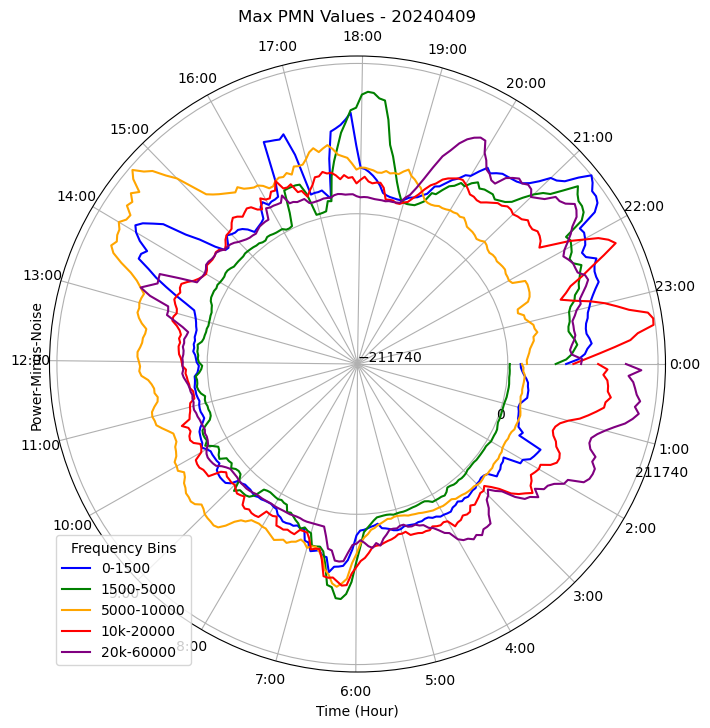

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


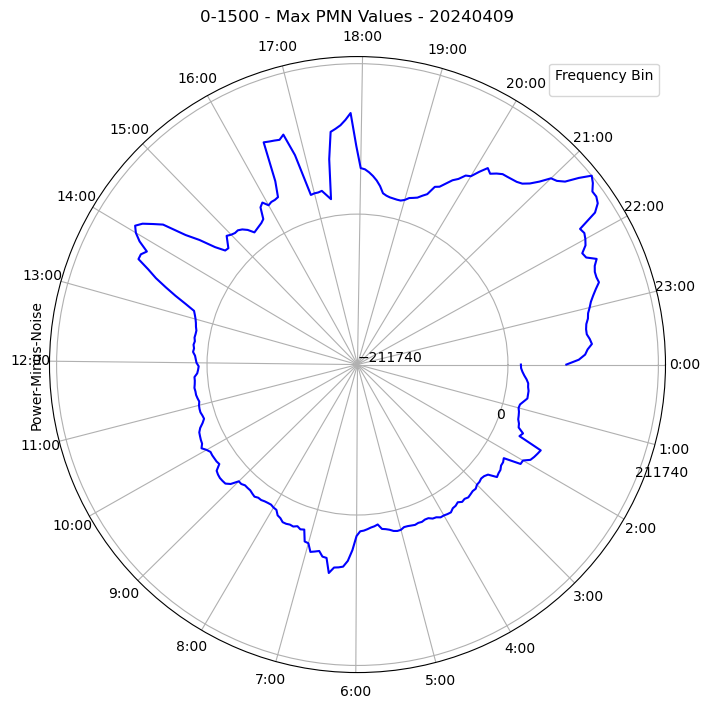

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


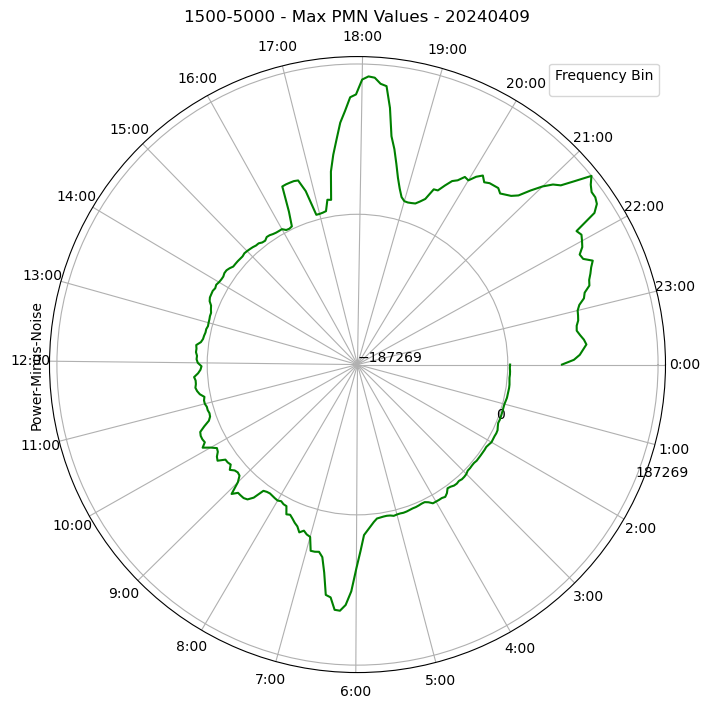

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


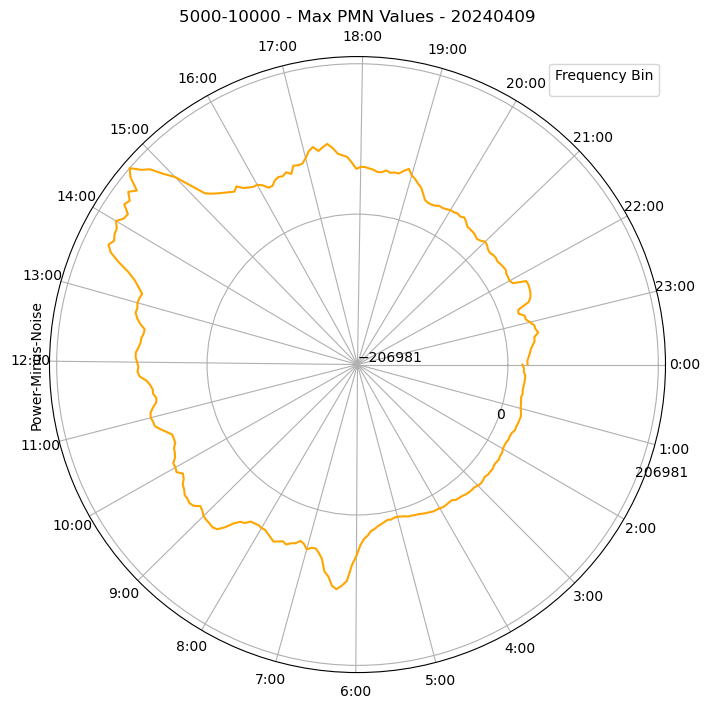

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


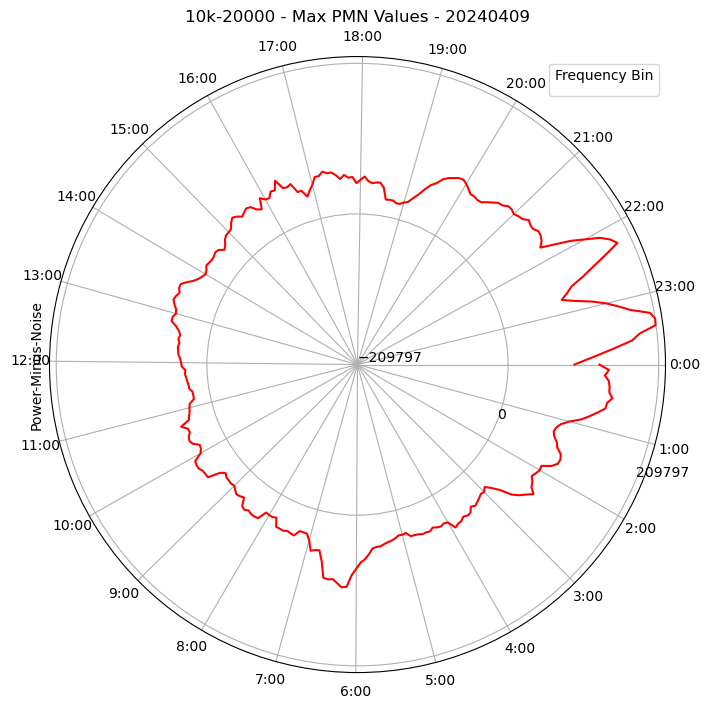

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


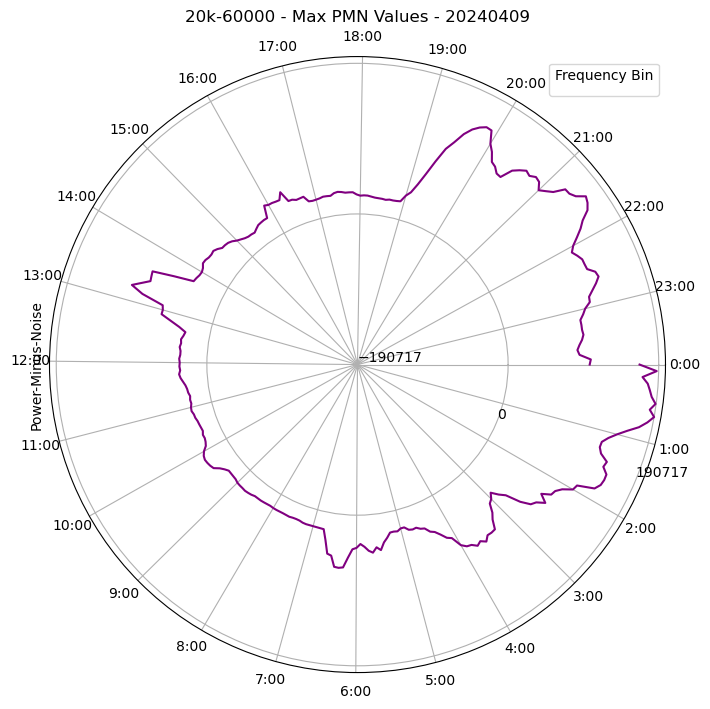

In [56]:

# Average All vs Individual
#plot_results(average_df_single, "Average PMN Values", chosen_day, save=False, save_path='/img/')
#plot_individual_bins(average_df_single, "Average PMN Values", chosen_day, save=True, save_path='img/')

# Median All vs Individual
#plot_results(median_df_single, "Median PMN Values", chosen_day, save=False, save_path= drive + '/img/')
#plot_individual_bins(median_df_single, "Median PMN Values", chosen_day, save=True, save_path='img/')

# Maximum All vs Individual
plot_results_polar(max_df_single, "Max PMN Values", chosen_day, save=False, save_path= drive + '/img/')
plot_individual_bins_polar(max_df_single, "Max PMN Values", chosen_day, save=False, save_path= drive +'/img/')



# Plot mean and stddev of the maximum of PMN values for a frequency bin

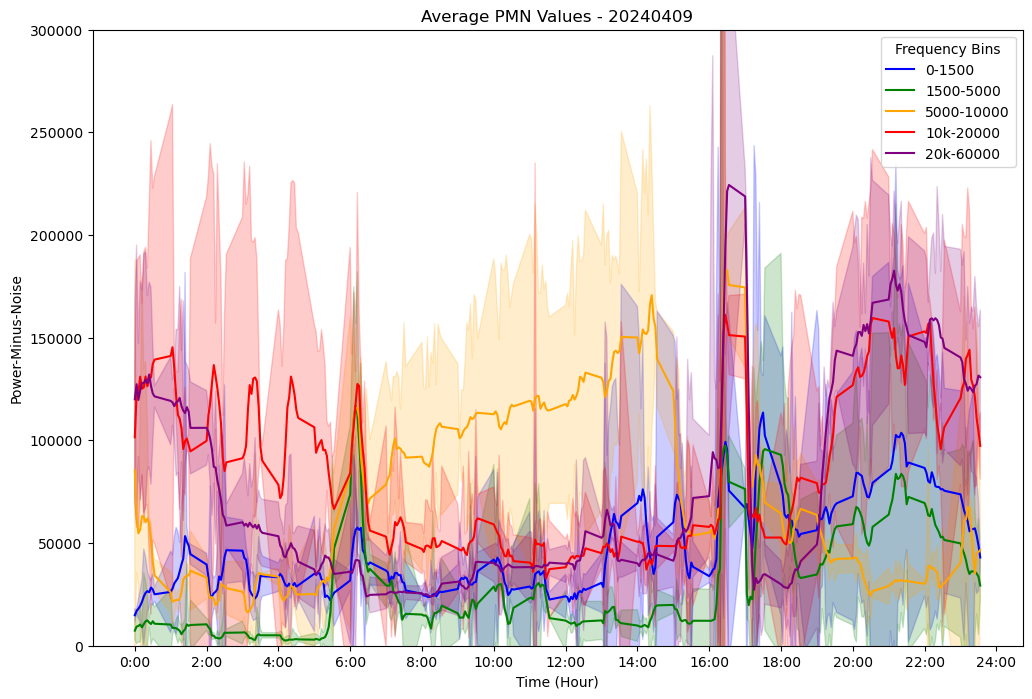

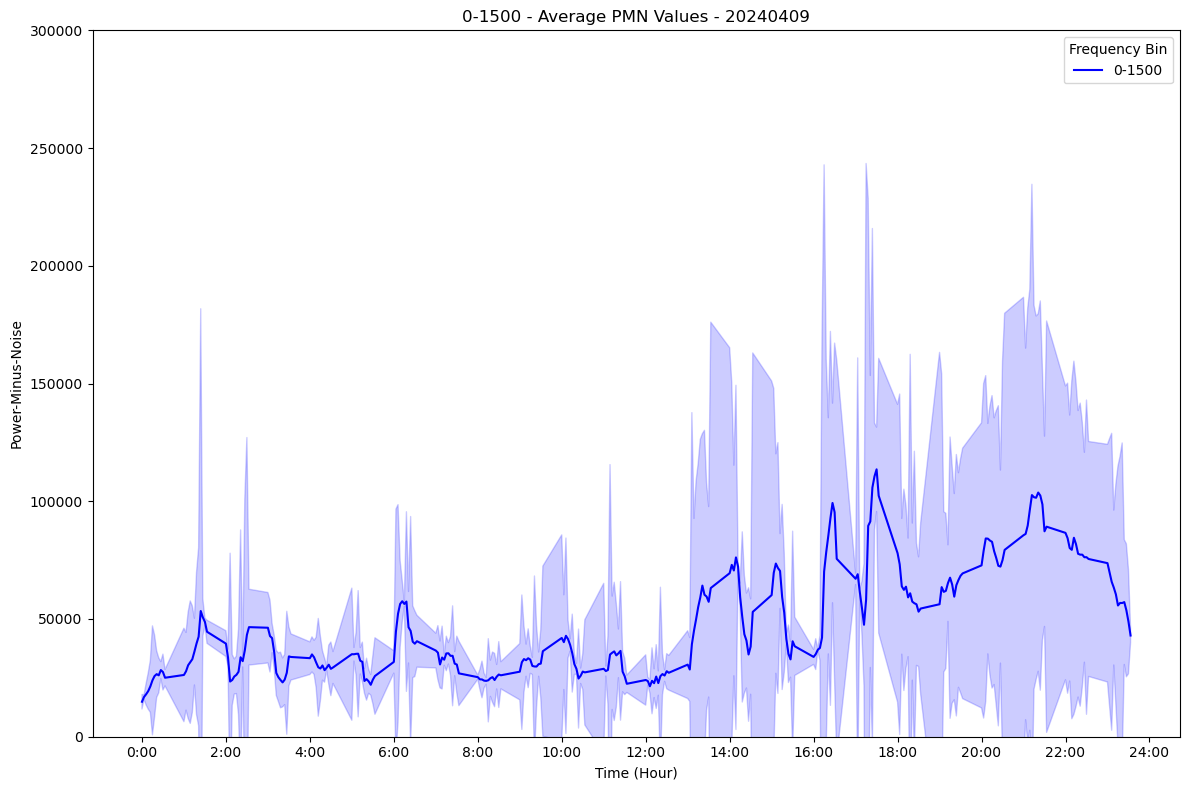

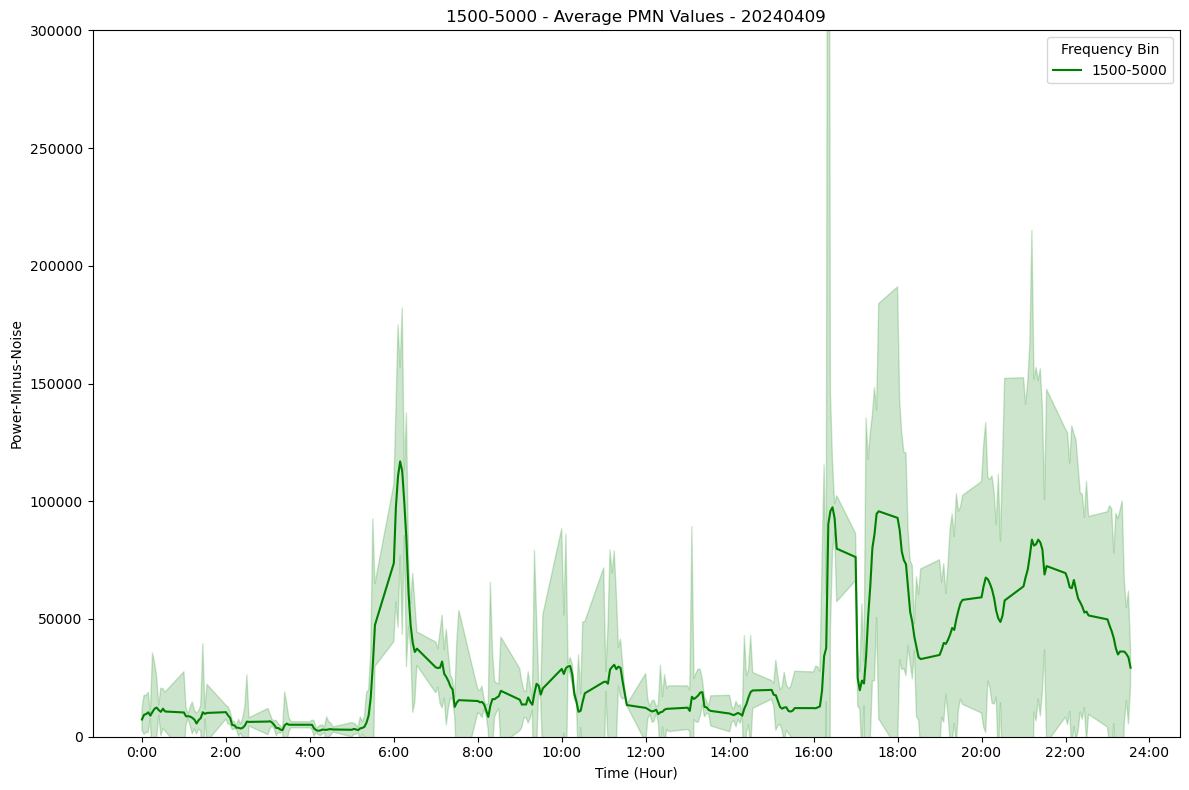

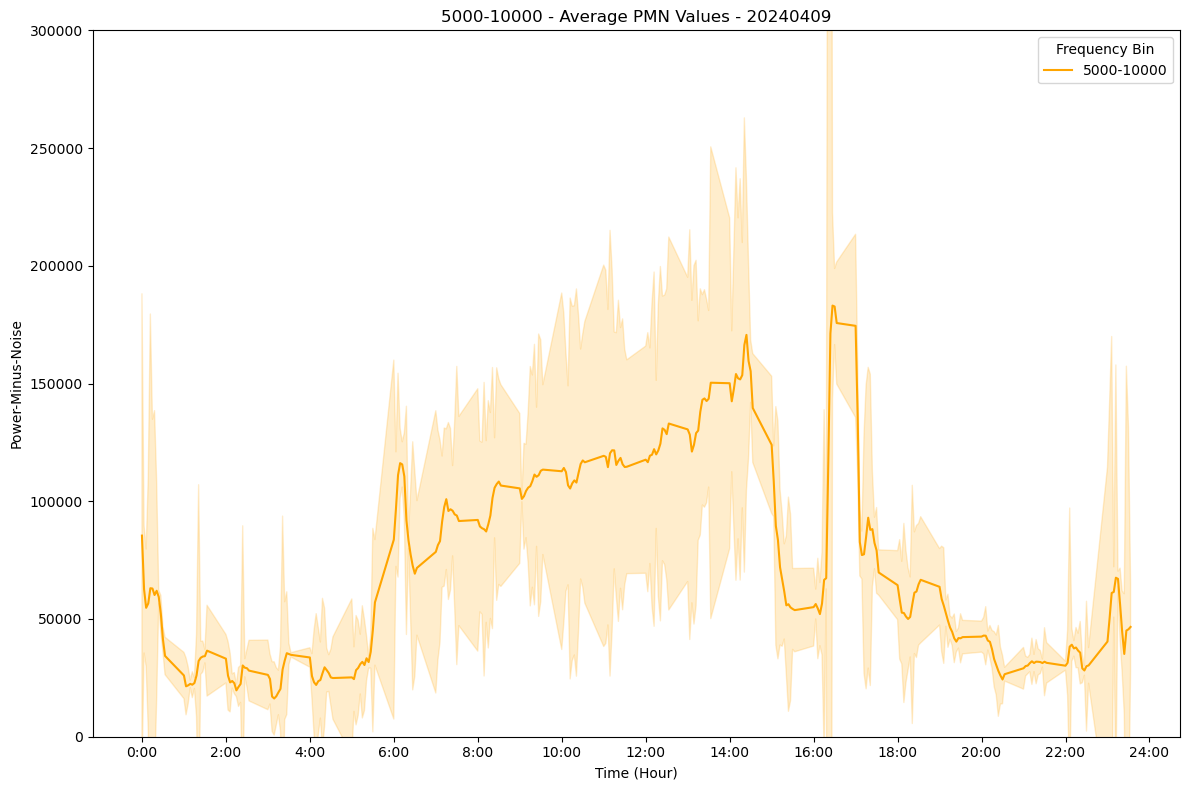

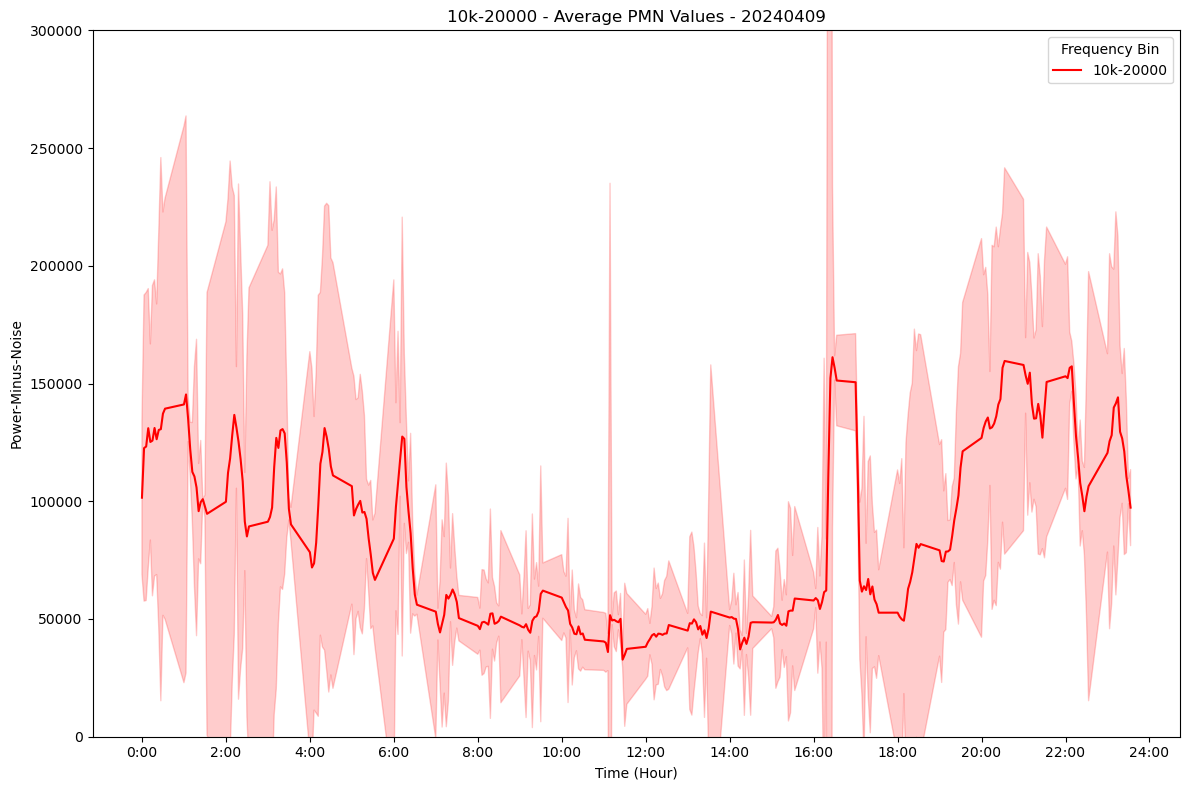

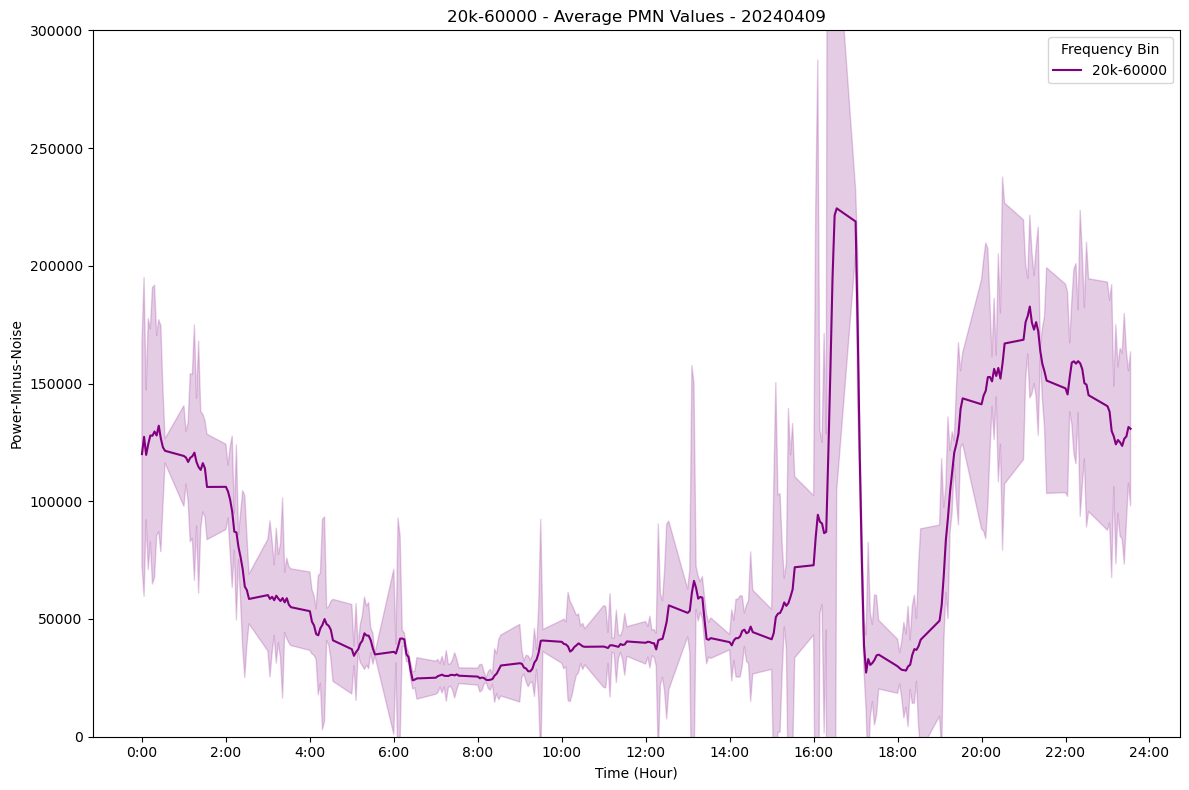

In [57]:
plot_results_line(
    max_df_final_mean, "Average PMN Values", chosen_day, save=False, save_path=drive + "/img/",std=max_df_final_std
)
plot_individual_bins_line(
    max_df_final_mean, "Average PMN Values", chosen_day, save=False, save_path=drive + "img/",std=max_df_final_std
)

# Plot all days and all bins (WARNING: Lots of plots)

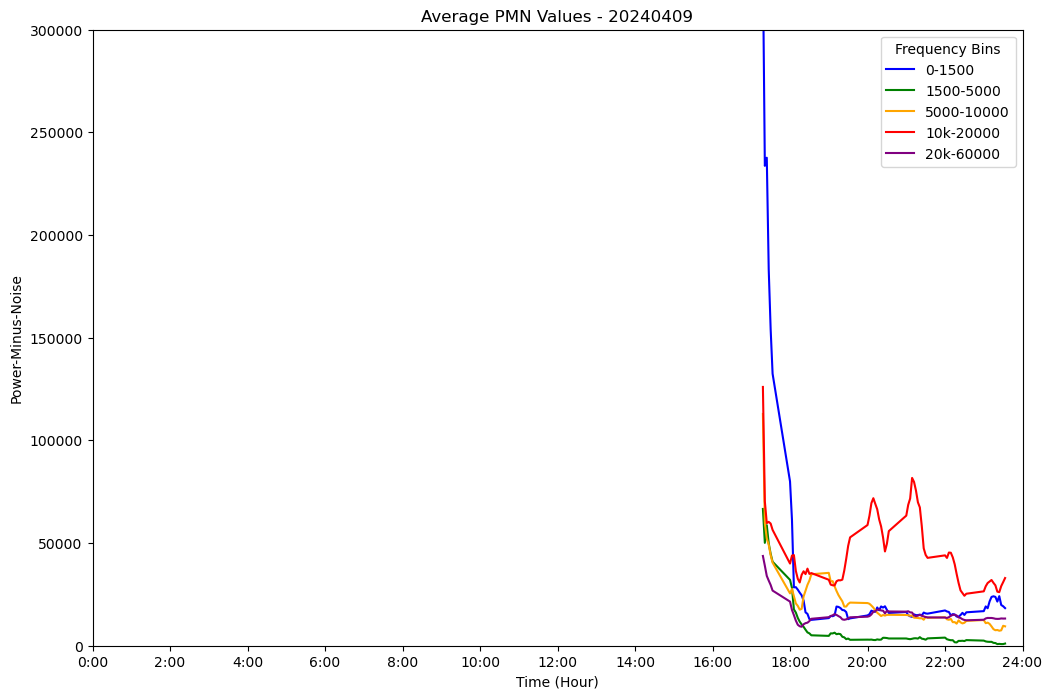

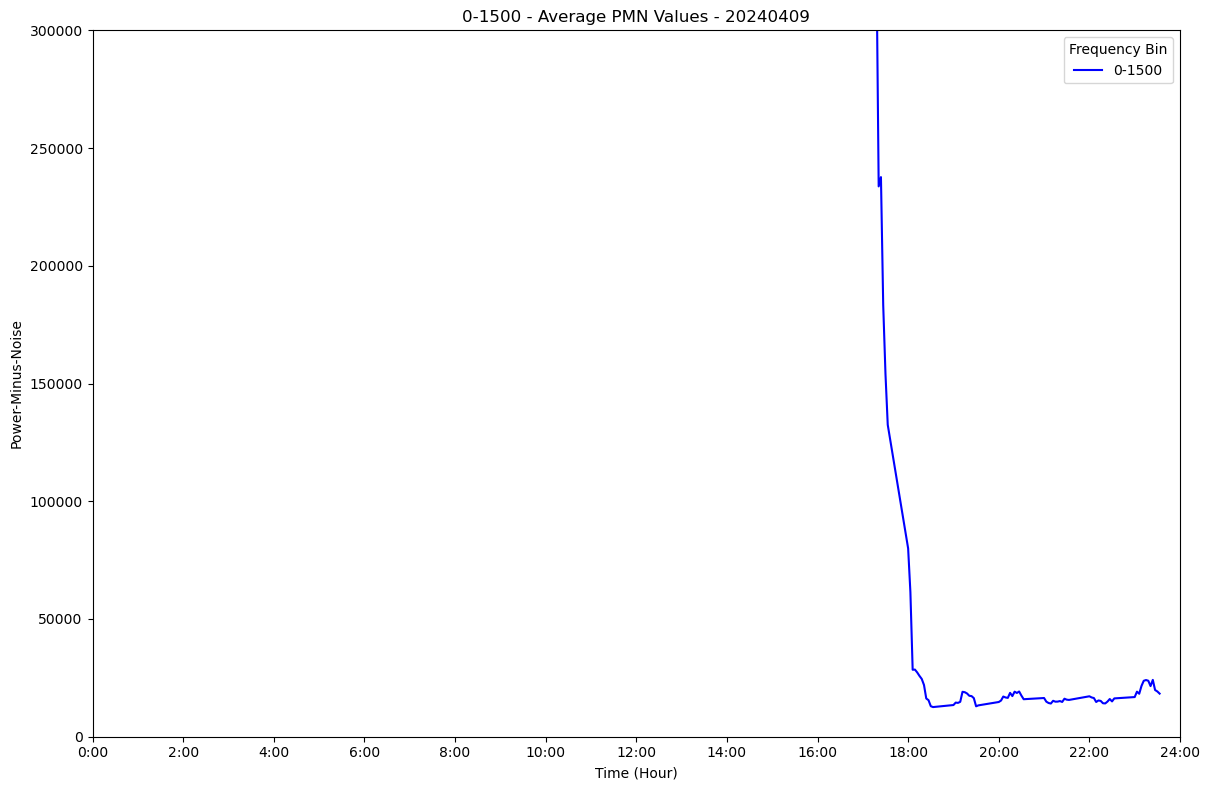

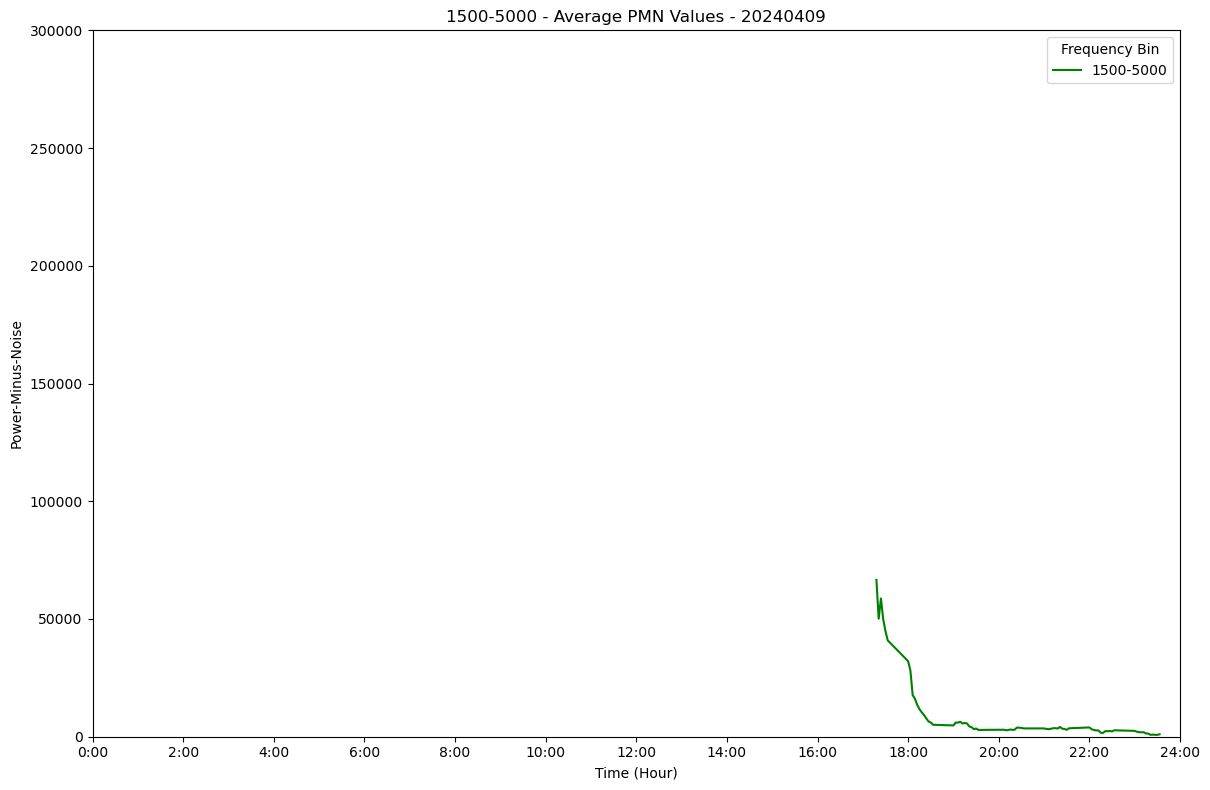

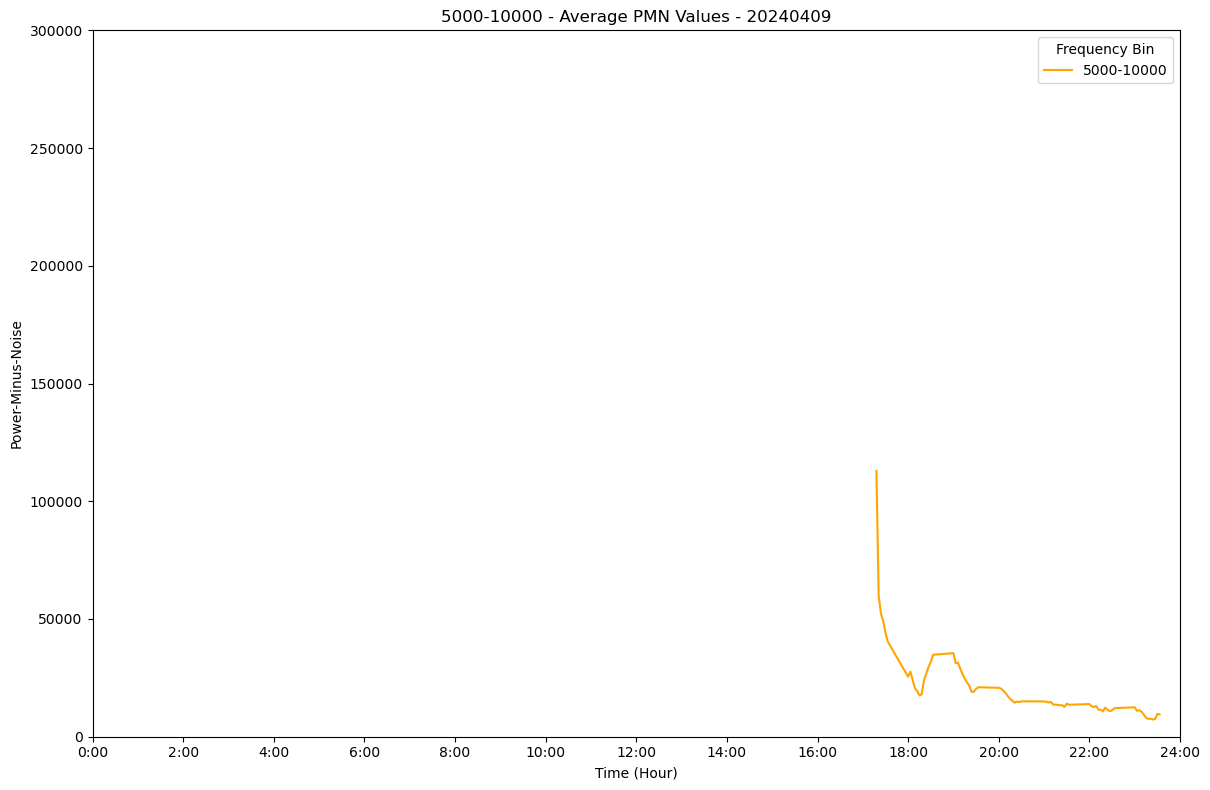

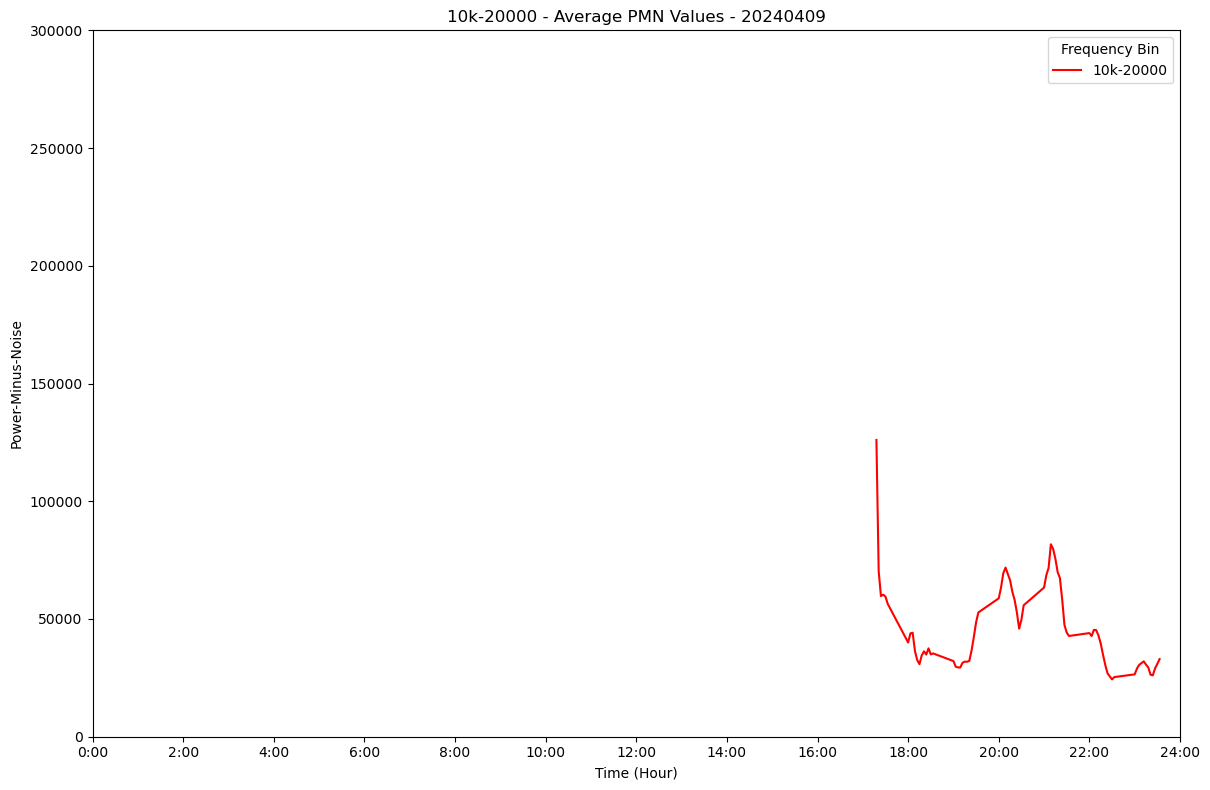

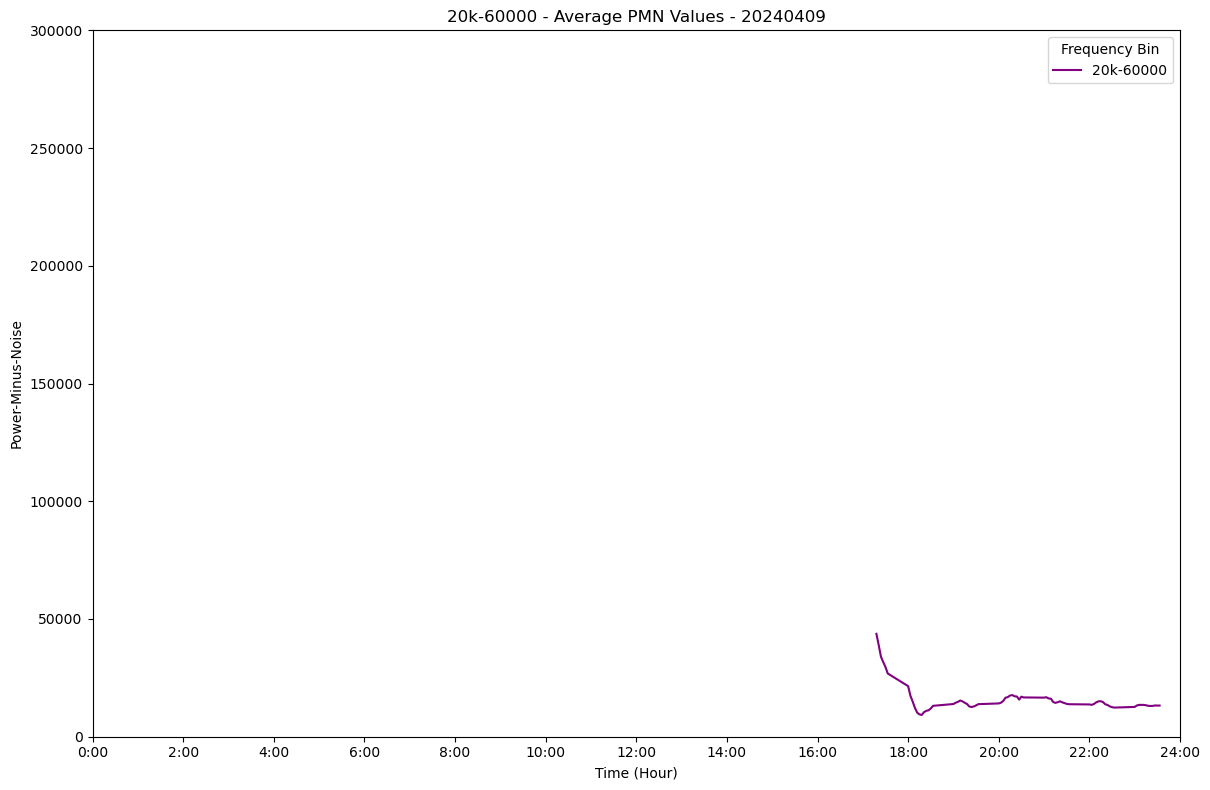

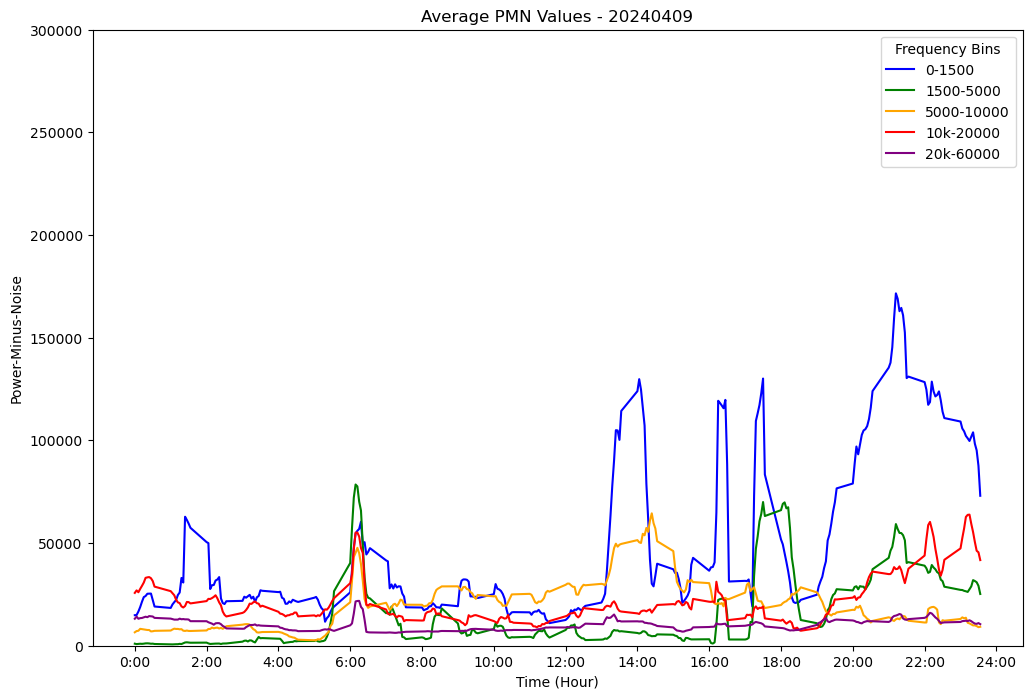

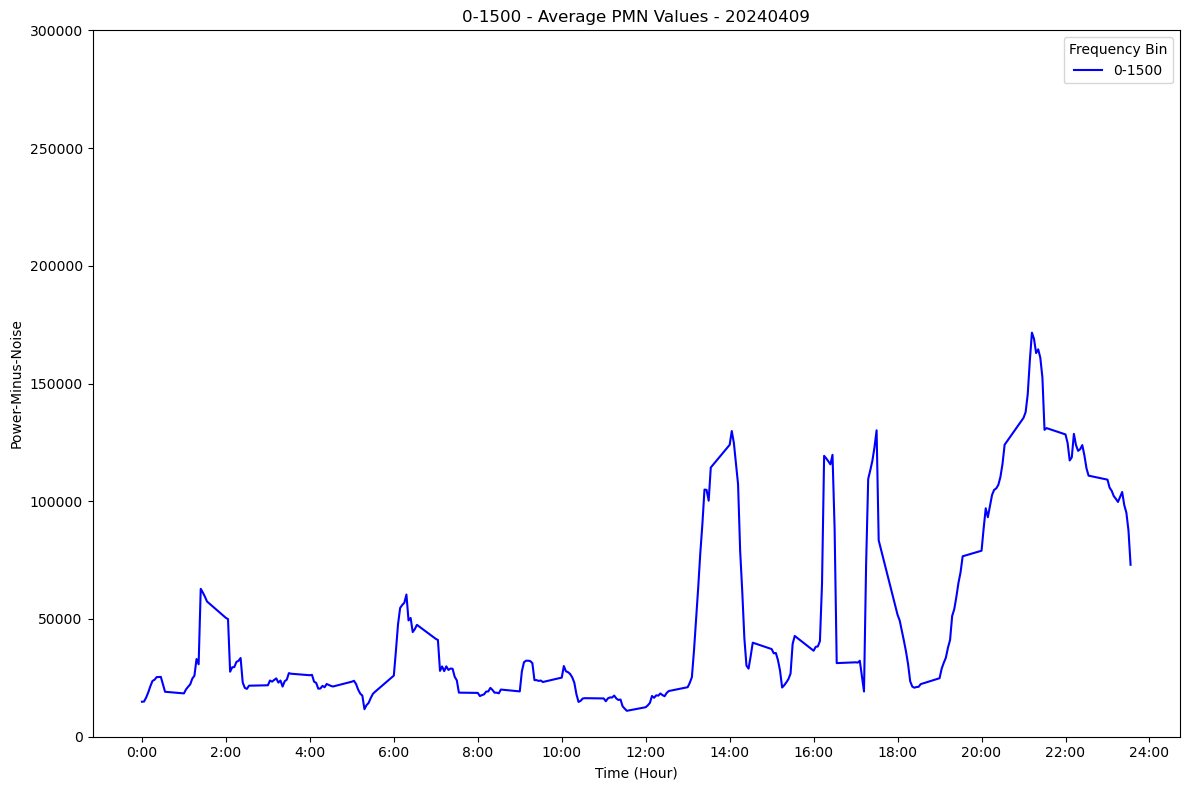

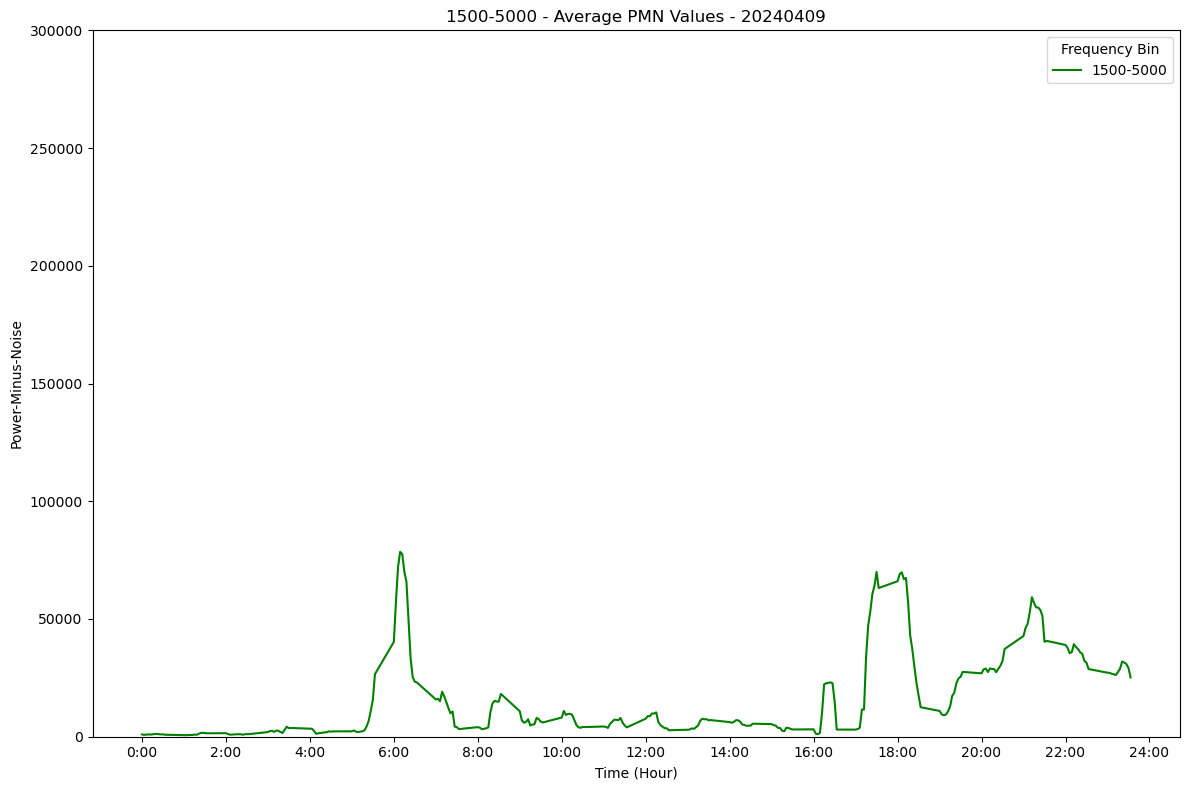

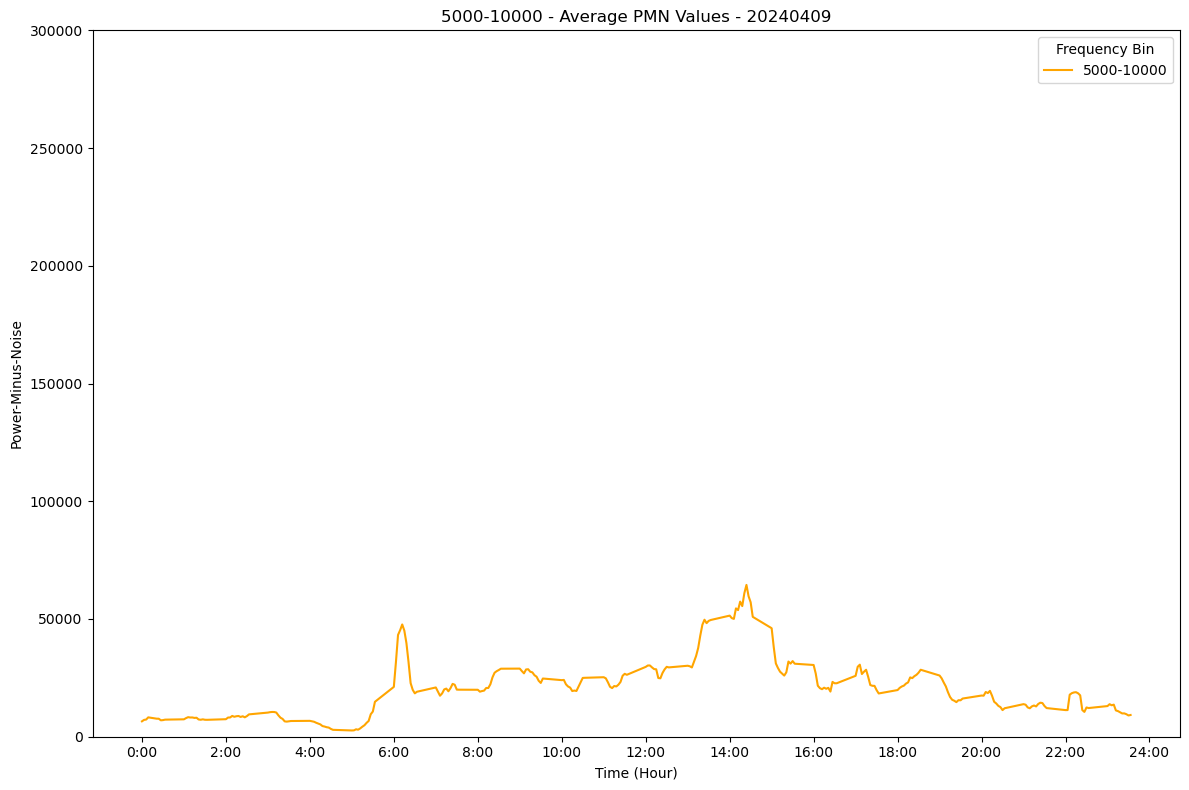

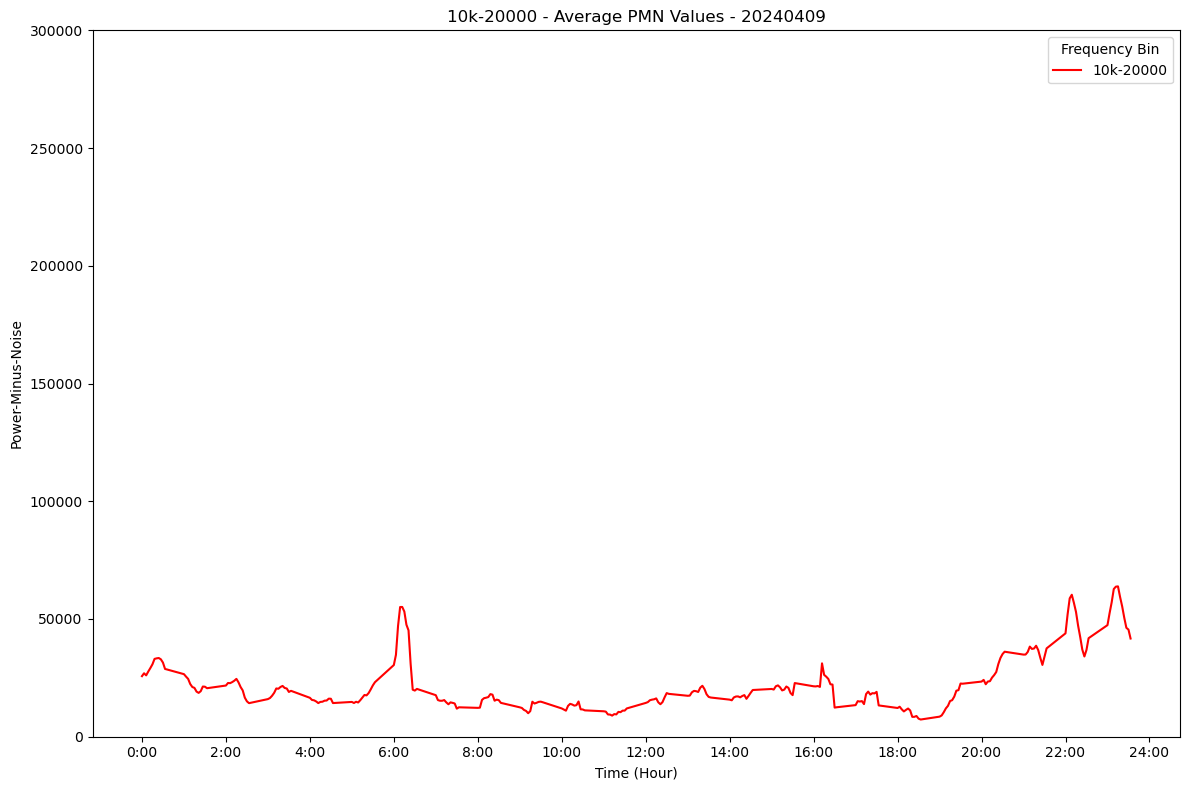

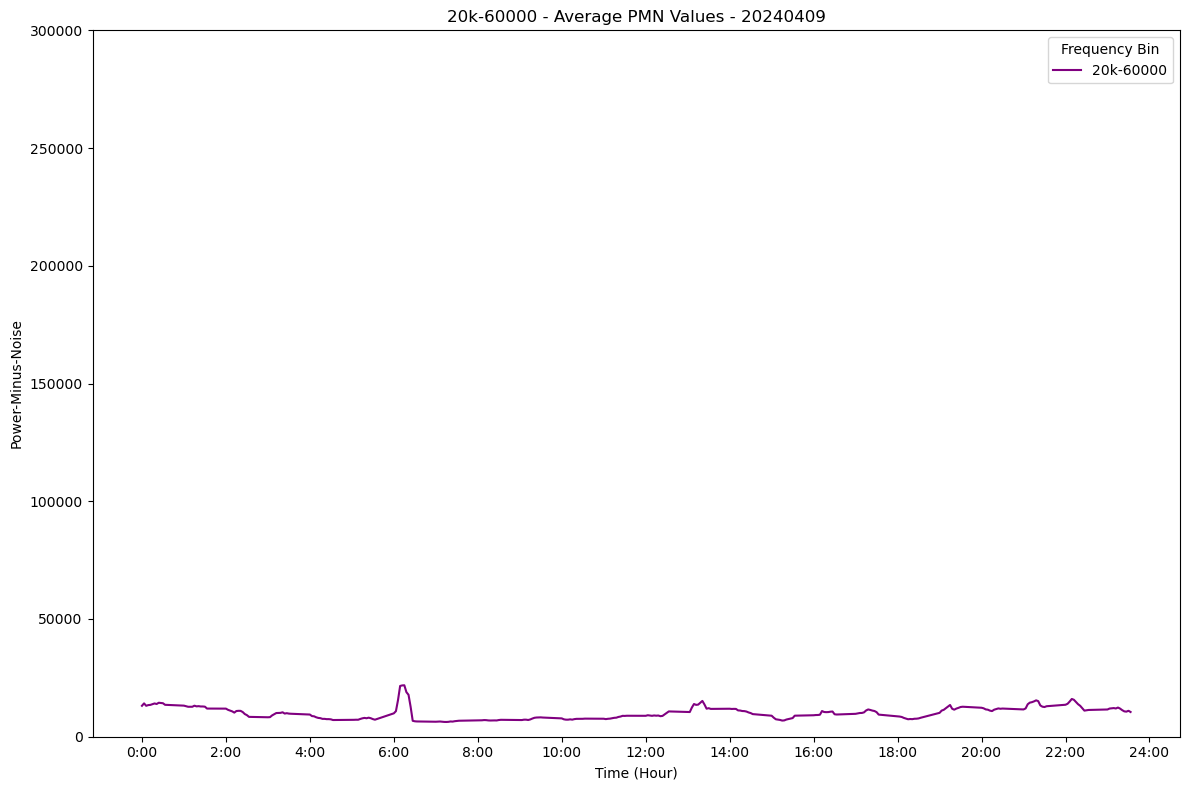

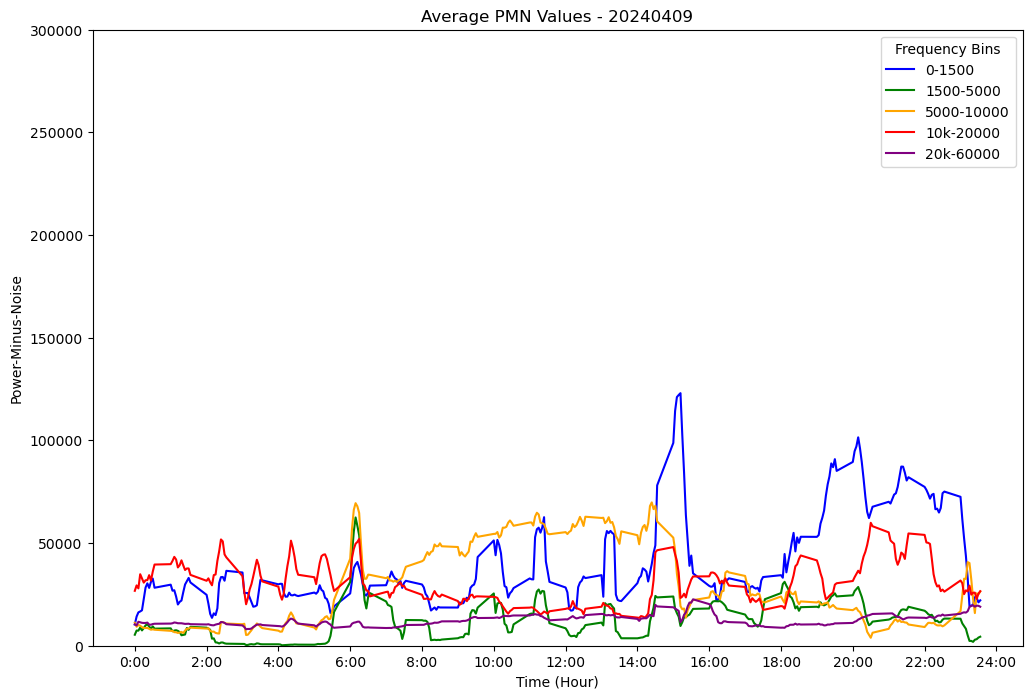

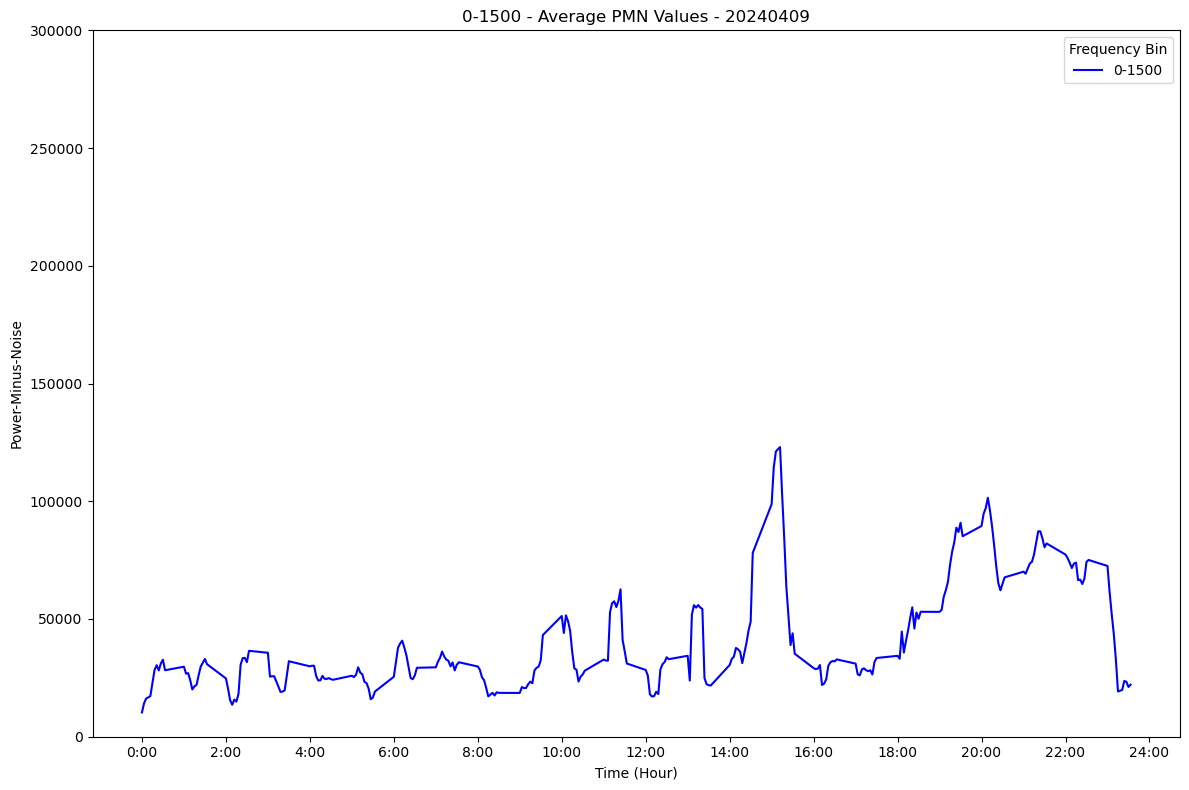

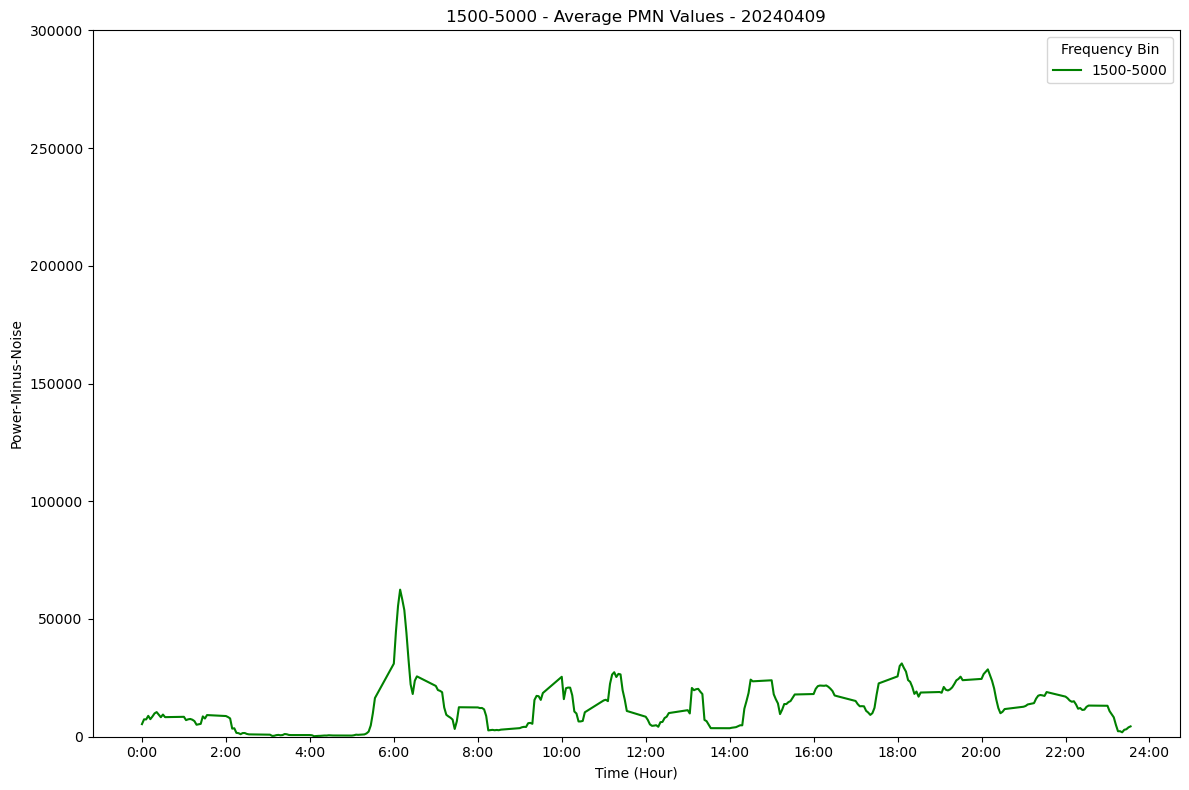

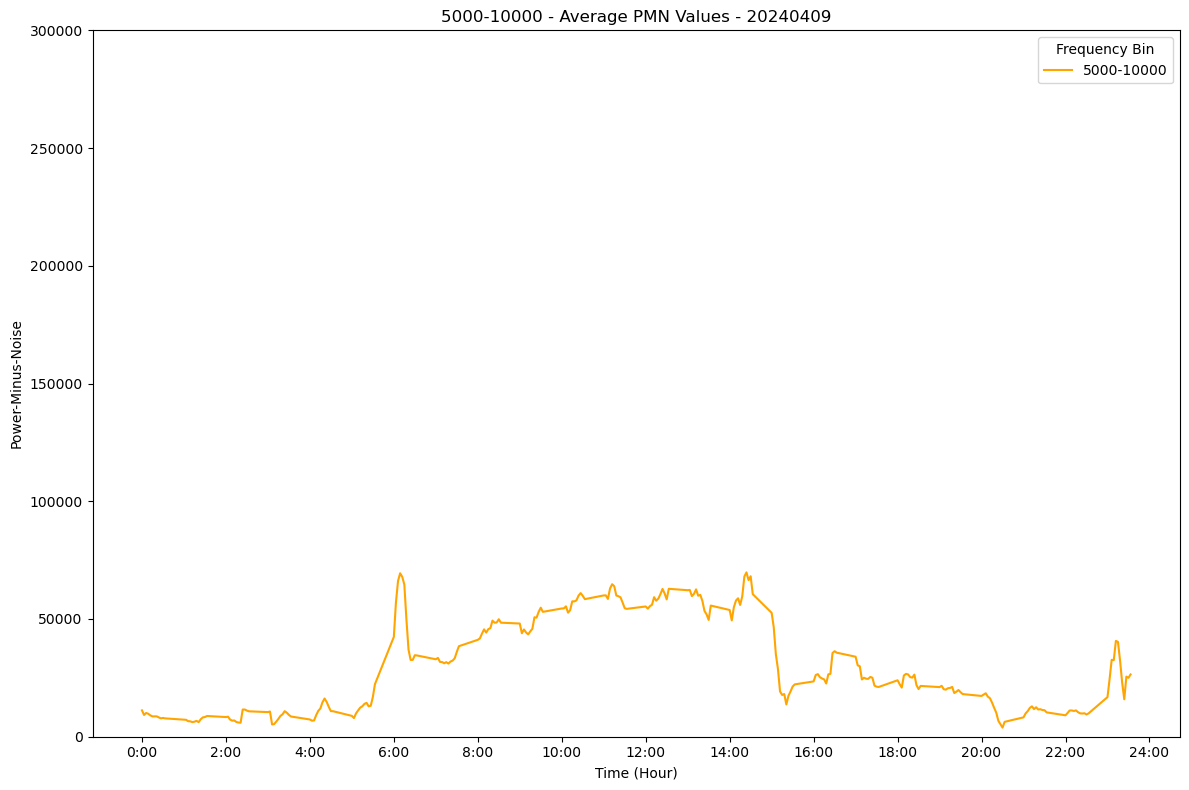

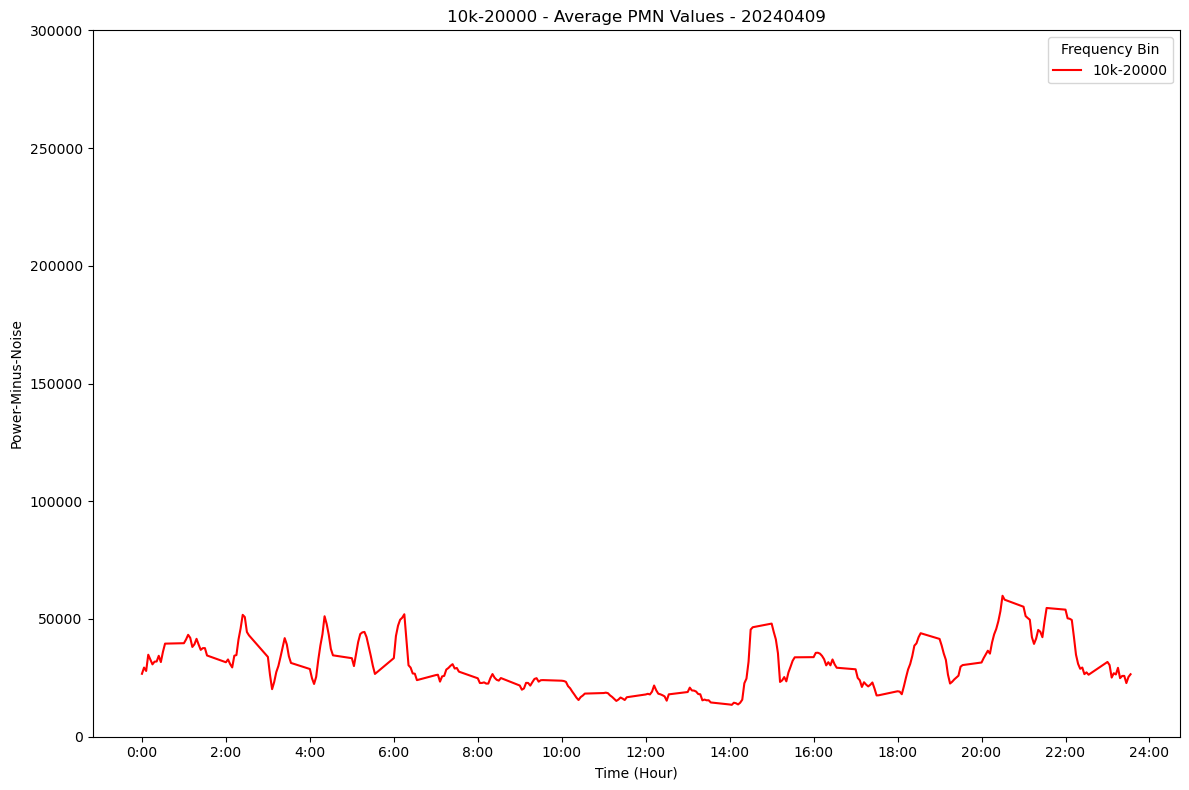

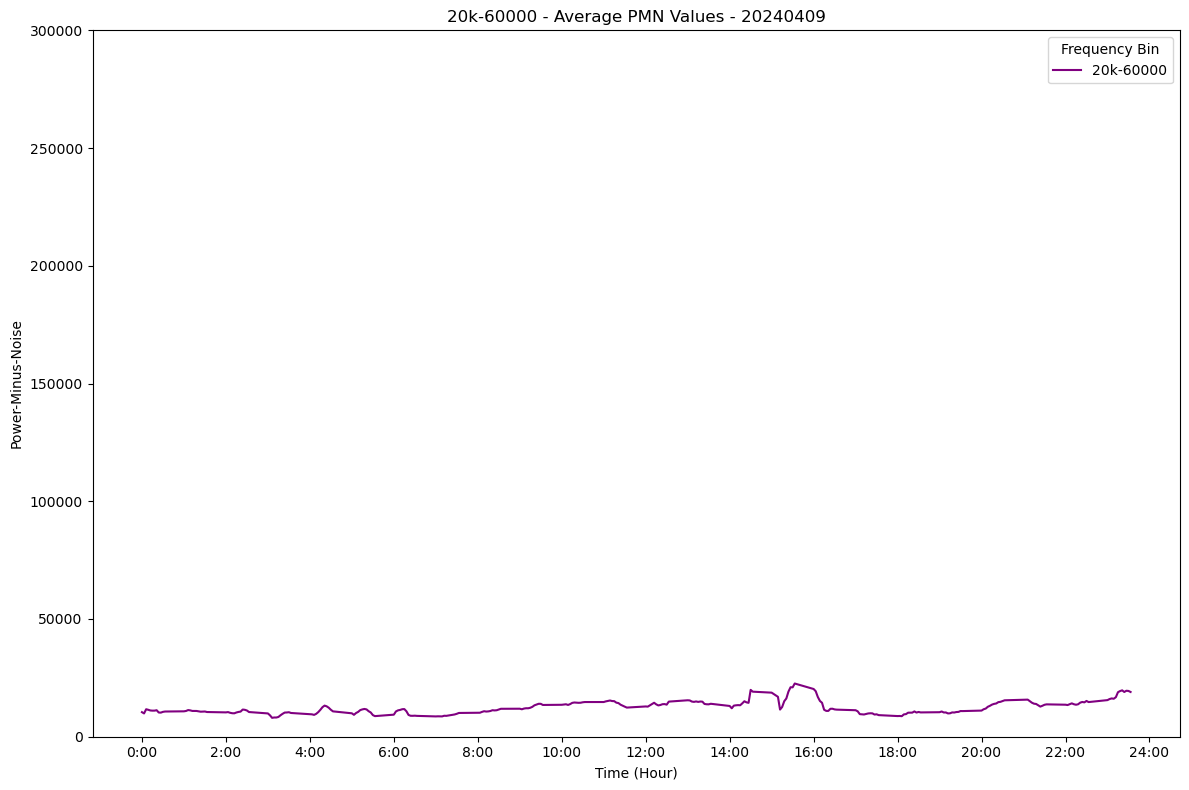

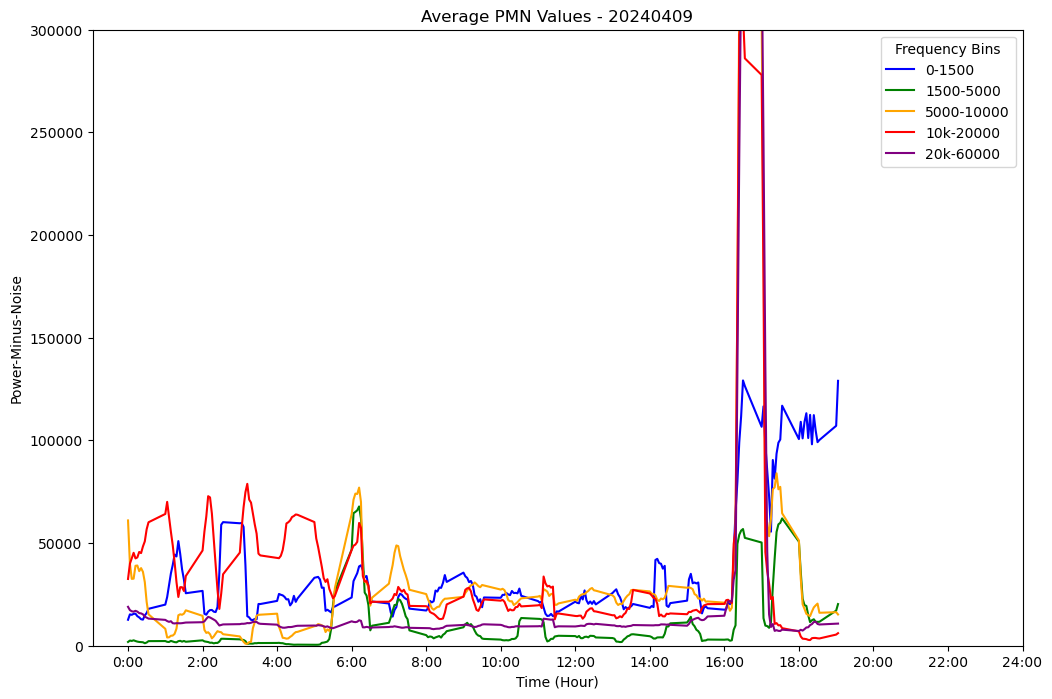

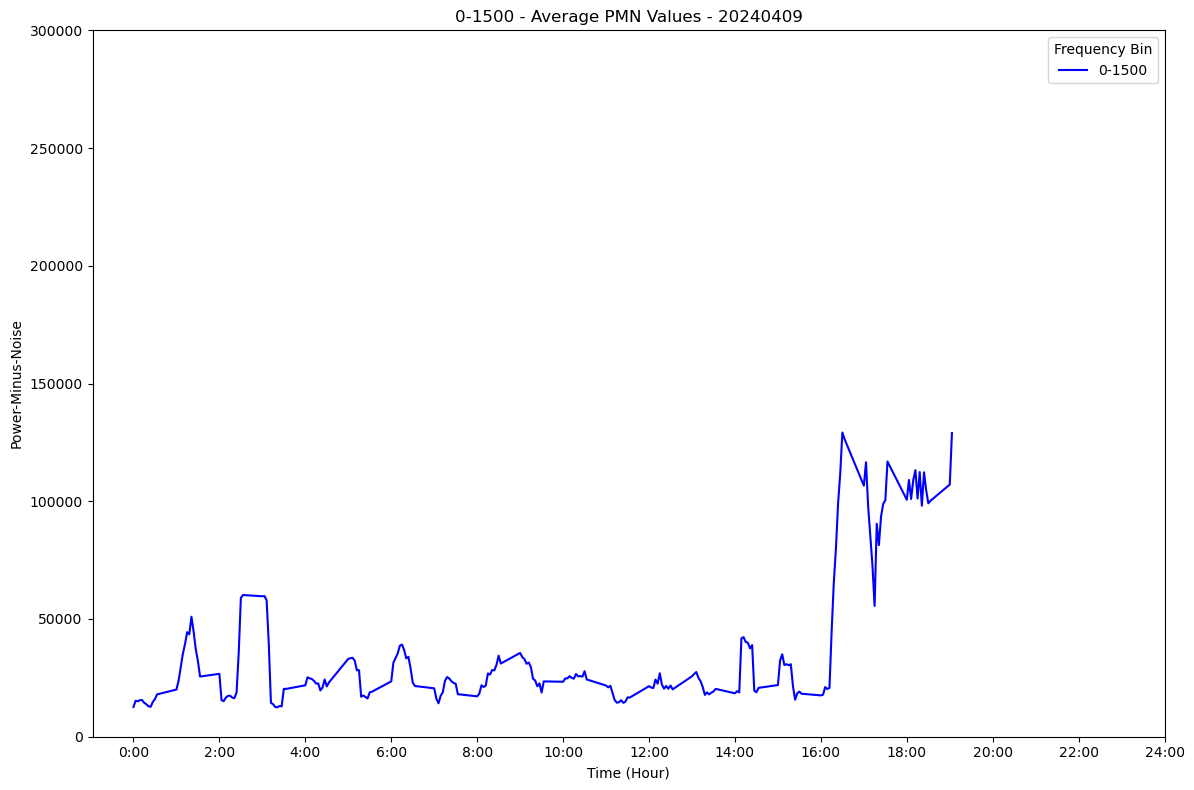

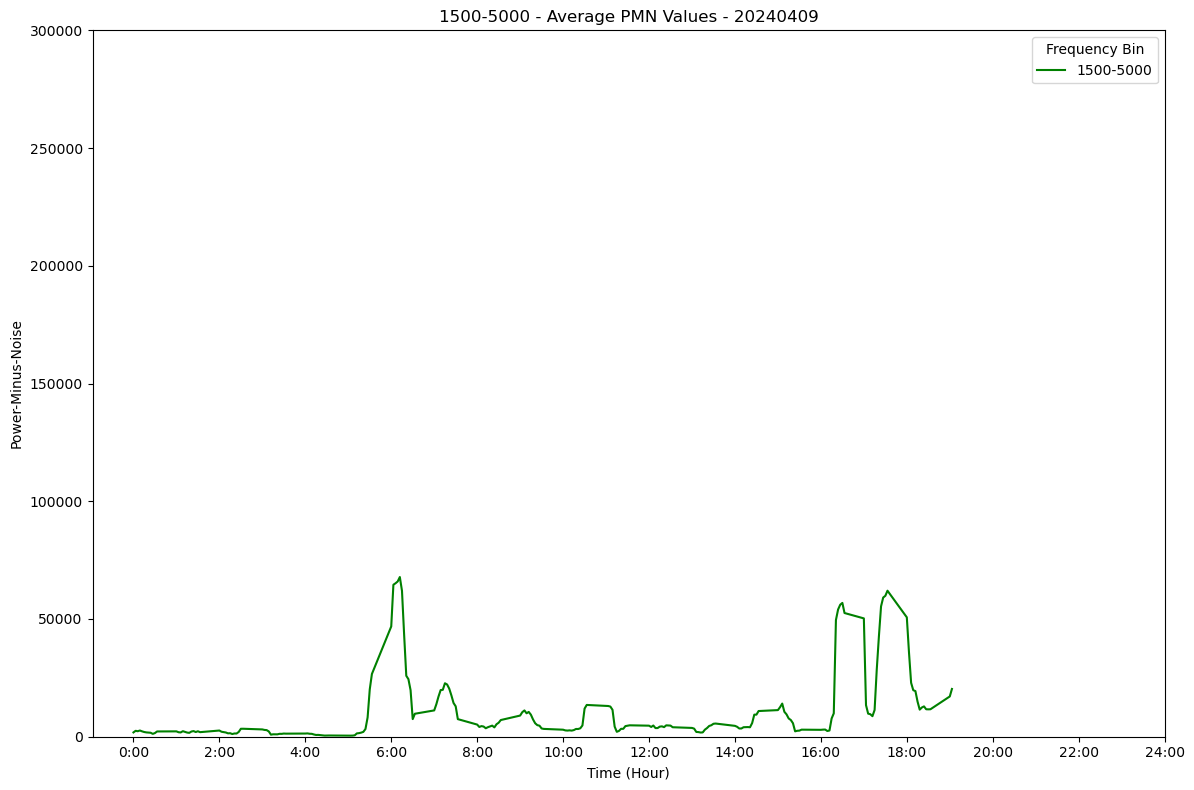

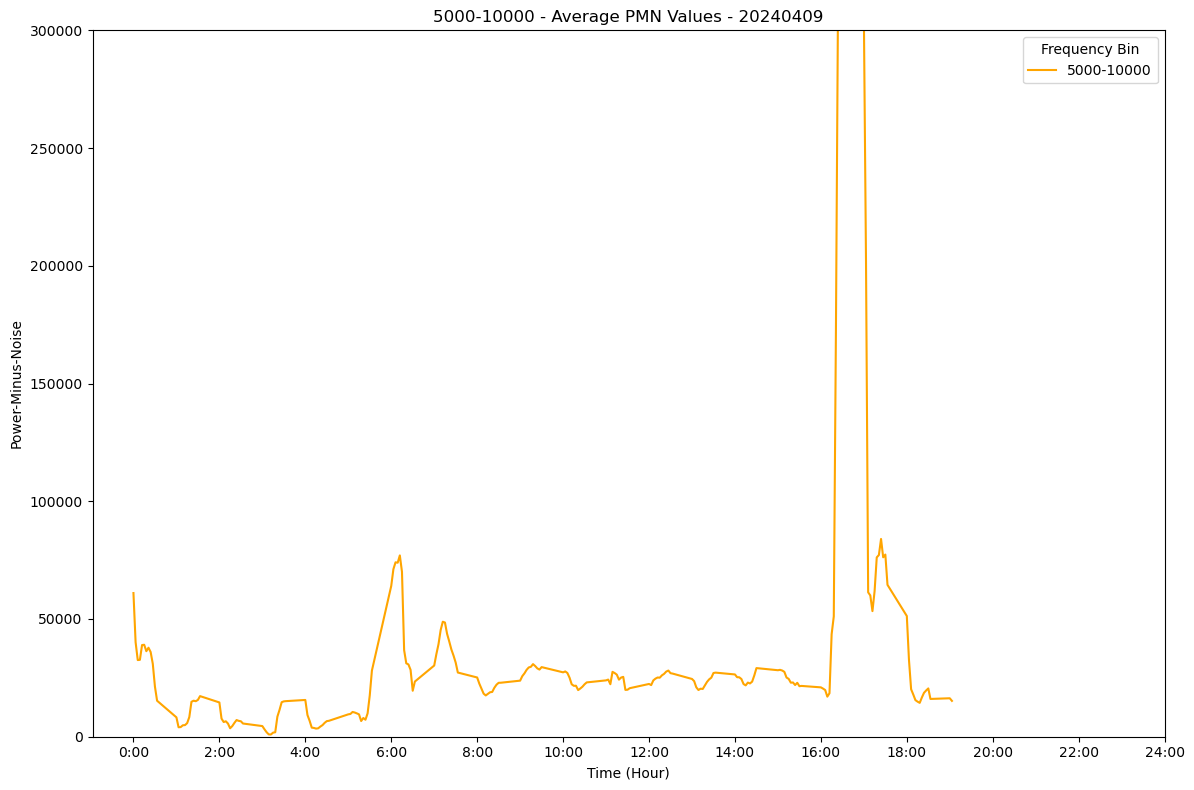

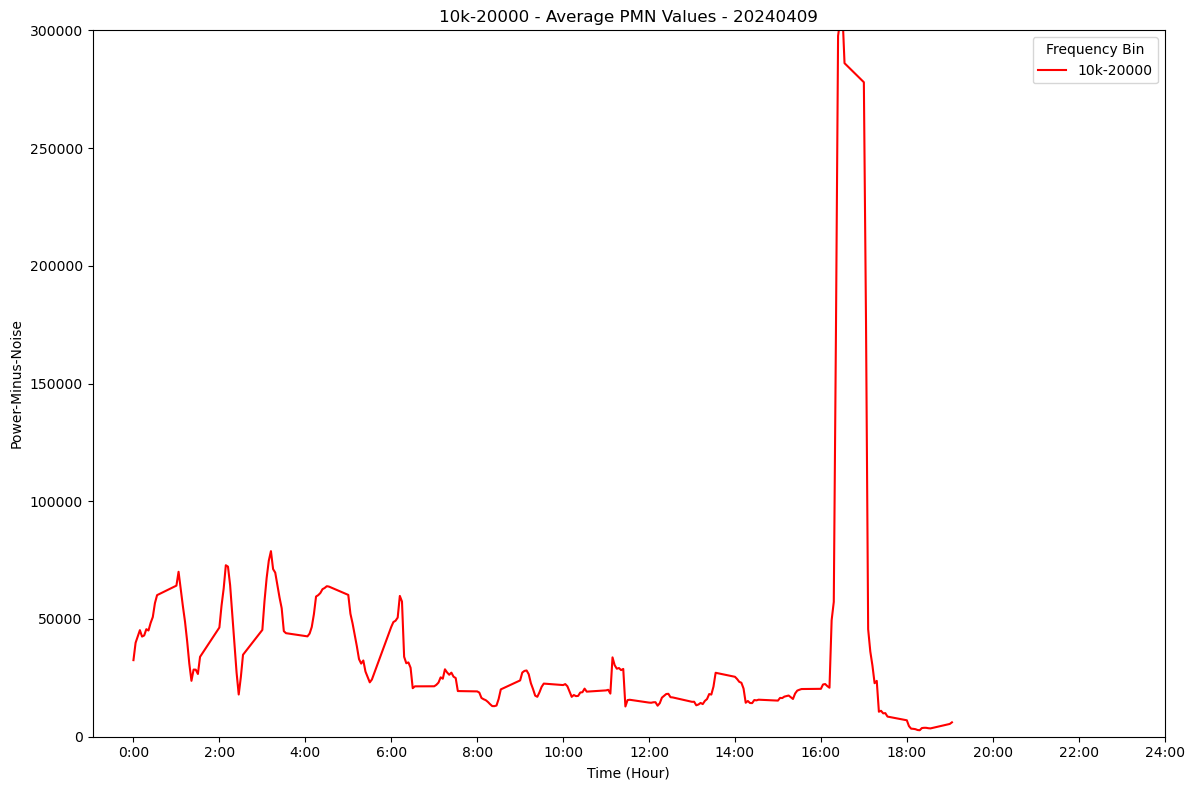

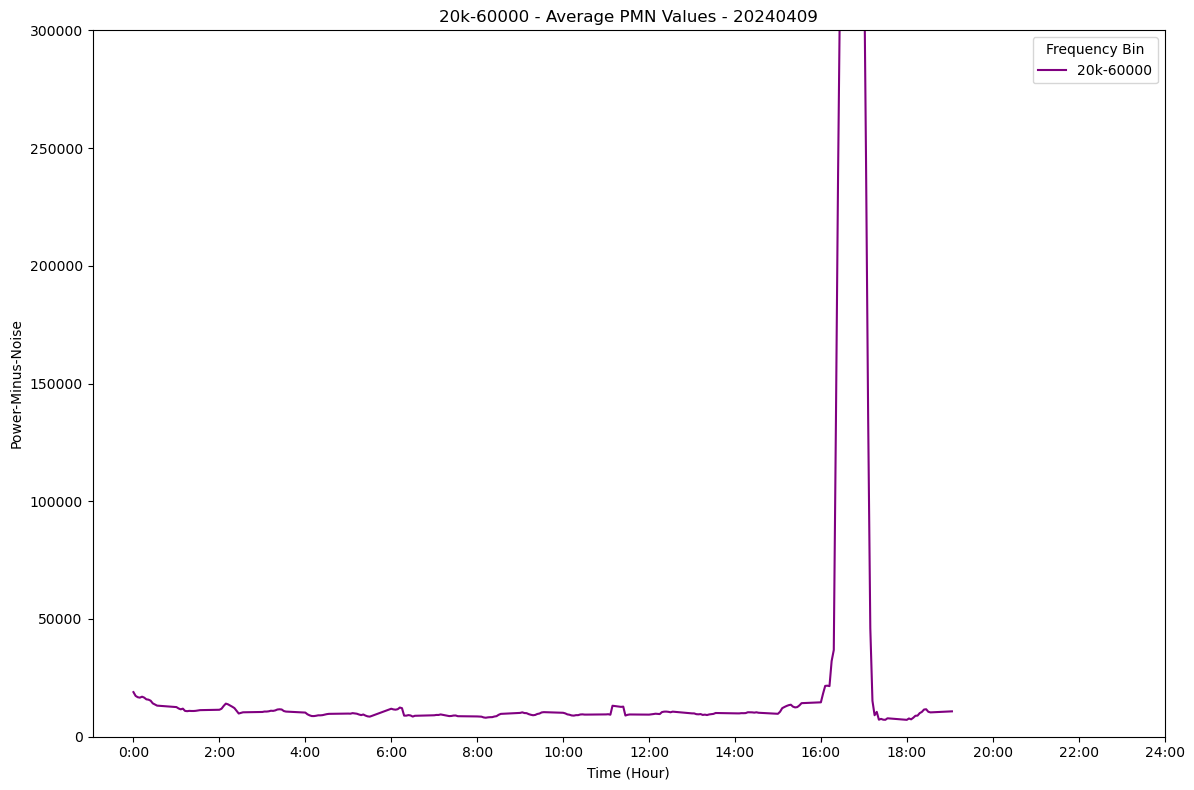

In [58]:
for average_df in average_df_list:
    plot_results_line(average_df, "Average PMN Values", chosen_day, save=False, save_path=drive + "/img/")
    plot_individual_bins_line(average_df, "Average PMN Values", chosen_day, save=False, save_path=drive + "/img/")
    

